<a href="https://colab.research.google.com/github/vardhamanadarsh/Punjab-state-finance-analysis-/blob/main/SF_Punjab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [118]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt

In [119]:
INPUT_FILE = "state_finance_analysis.XLSX"

if len(sys.argv) > 1 and sys.argv[1] != "-f":
    INPUT_FILE = sys.argv[1]
OUT_CHARTS = "output/charts"
OUT_TABLES = "output/tables"
os.makedirs(OUT_CHARTS, exist_ok=True)
os.makedirs(OUT_TABLES, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 130,
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

In [120]:
COLOR_A = "#1f5f8b"   # steel blue
COLOR_B = "#e0793c"   # burnt orange
COLOR_C = "#c0392b"   # red (danger / threshold)
COLOR_D = "#2e8b57"   # green (positive)

COLOR_PUNJAB = "#c0392b"
COLOR_OTHER = "#4a90e2"
COLOR_PEER = {"Punjab": "#c0392b", "Kerala": "#e0793c", "Rajasthan": "#2e8b57",
              "West Bengal": "#6a4c93", "Himachal Pradesh": "#1f5f8b", "Andhra Pradesh": "#999999"}

In [121]:
def savefig(fig, name):
    """Shared save helper used by every chart in both parts."""
    path = os.path.join(OUT_CHARTS, name)
    fig.tight_layout()
    fig.savefig(path, bbox_inches="tight")
    plt.close(fig)
    print(f"saved: {path}")


def thin_xticks(ax, labels, step=3):
    """Show every Nth year label so the x-axis doesn't get crowded. (Part 1 only)"""
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(
        [lab if i % step == 0 else "" for i, lab in enumerate(labels)],
        rotation=45, ha="right"
    )


def shorten_fy(y):
    start, end = y.split("-")
    return f"'{start[-2:]}-'{end[-2:]}"

In [122]:
#LOAD + FILTER TO PUNJAB, ACCOUNT (ACTUAL) DATA ONLY
def load_punjab_actuals(path):
    df = pd.read_excel(path, sheet_name="Data")
    pb = df[df["State/UT"] == "Punjab"].copy()

    heads = [
        "Total: TOTAL REVENUE (I+II)",
        "Total: TOTAL EXPENDITURE (I+II+III)",
        "I: TAX REVENUE (A+B)",
        "I.A: State's Own Tax Revenue (1 to 3)",
        "I.B: Share in Central Taxes (i to ix)",
        "II: NON-TAX REVENUE (C+D)",
        "II.D: Grants from the Centre (1 to 7)",
        "II.C.2: Interest Payments (i to iv)",
        "II.E: Pensions",
        "I: Internal Debt (1 to 8)",
        "I.1: Market Loans",
        "I.4: Loans from SBI and other Banks",
        "I.6: WMA from RBI",
        "I.7: Special Securities issued to NSSF",
        "II: Loans and Advances from the Centre (1 to 8)",
        "II: Discharge of Internal Debt (1 to 8)",
        "A: Surplus (+)/Deficit (-) on Revenue Account",
        "C: Overall Surplus (+)/Deficit (-) (A+B)",
        "I: Total Capital Outlay (1 + 2)",
        "II.C.3.0: of which: State Lotteries",
        "IV: Loans and Advances by State Governments (1+2)",
        "i.a: Opening Balance",
        "i.b: Closing Balance",
        "iii: Increase (-)/Decrease (+) in Ways and Means Advances and Overdrafts from RBI (net)",
        "II.C.1: Appropriation for Reduction or Avoidance of Debt",
        "II.D.5.c.1: GST compensation",
        "II.D.7.i: GST Compensation (1)#",
        "II.D.7.ii: GST Compensation (2)#",
        # ---borrowing/repayment heads ---
        "II.C.1: Interest Receipts",
        "II.C.2.i: Interest on Loans from the Centre",
        "II.C.2.ii.b: Interest on NSSF",
        "II.C.2.iii: Interest on Small Savings, State Provident Funds, etc.",
        "III: Recovery of Loans and Advances (1 to 12)",
        "VI.1: State Provident Funds",
        "VII.2: Sinking Funds",
        "VIII.2: Sinking Funds",
        "IX: Deposits and Advances (1 to 4)",
        "VIII: Deposits and Advances (1 to 4)",
    ]

    sub = pb[pb["Budget Head"].isin(heads)][["Budget Head", "Fiscal Year", "Account"]]
    piv = sub.pivot_table(index="Fiscal Year", columns="Budget Head",
                           values="Account", aggfunc="first")

    # keeping only years where an actual figure exists (drops years that are BE/RE only)
    piv = piv.dropna(subset=["Total: TOTAL REVENUE (I+II)"])
    piv = piv.sort_index()

    # merging the two GST-compensation head variants (head name changed in 2020-21)
    gst_old = piv.get("II.D.5.c.1: GST compensation", pd.Series(0, index=piv.index)).fillna(0)
    gst_new = piv.get("II.D.7.ii: GST Compensation (2)#", pd.Series(0, index=piv.index)).fillna(0)
    piv["GST_Compensation_Actual"] = gst_old + gst_new

    return piv


piv = load_punjab_actuals(INPUT_FILE)
years = piv.index.tolist()
years_short = [shorten_fy(y) for y in years]  # e.g. '1990-1991' -> ''90-'91'

In [123]:
revenue      = piv["Total: TOTAL REVENUE (I+II)"]
expenditure  = piv["Total: TOTAL EXPENDITURE (I+II+III)"]
interest     = piv["II.C.2: Interest Payments (i to iv)"]
discharge    = piv["II: Discharge of Internal Debt (1 to 8)"]
debt_raised  = piv["I: Internal Debt (1 to 8)"]
market_loans = piv["I.1: Market Loans"]
sbi_loans    = piv["I.4: Loans from SBI and other Banks"]
wma_gross    = piv["I.6: WMA from RBI"]
wma_net      = piv["iii: Increase (-)/Decrease (+) in Ways and Means Advances and Overdrafts from RBI (net)"]
nssf         = piv["I.7: Special Securities issued to NSSF"]
capital_out  = piv["I: Total Capital Outlay (1 + 2)"]
lottery      = piv["II.C.3.0: of which: State Lotteries"]
onlending    = piv["IV: Loans and Advances by State Governments (1+2)"]
open_bal     = piv["i.a: Opening Balance"]
close_bal    = piv["i.b: Closing Balance"]
sinking_fund = piv["II.C.1: Appropriation for Reduction or Avoidance of Debt"].fillna(0)
own_tax      = piv["I.A: State's Own Tax Revenue (1 to 3)"]
central_tax  = piv["I.B: Share in Central Taxes (i to ix)"]
grants       = piv["II.D: Grants from the Centre (1 to 7)"]
rev_deficit  = piv["A: Surplus (+)/Deficit (-) on Revenue Account"]
gst_comp     = piv["GST_Compensation_Actual"]

# ---borrowing/repayment series ---
int_receipts   = piv["II.C.1: Interest Receipts"]
int_to_centre  = piv["II.C.2.i: Interest on Loans from the Centre"]
nssf_interest  = piv["II.C.2.ii.b: Interest on NSSF"]
pf_interest    = piv["II.C.2.iii: Interest on Small Savings, State Provident Funds, etc."]
loan_recovery  = piv["III: Recovery of Loans and Advances (1 to 12)"]
prov_fund      = piv["VI.1: State Provident Funds"]
sinking_fund2  = piv[["VII.2: Sinking Funds", "VIII.2: Sinking Funds"]].bfill(axis=1).iloc[:, 0].fillna(0)
deposits_adv   = piv[["IX: Deposits and Advances (1 to 4)", "VIII: Deposits and Advances (1 to 4)"]].bfill(axis=1).iloc[:, 0]

debt_service        = interest + discharge
debt_service_pct    = (debt_service / revenue * 100).round(1)
central_dependency  = ((central_tax + grants) / revenue * 100).round(1)
own_revenue_pct     = 100 - central_dependency

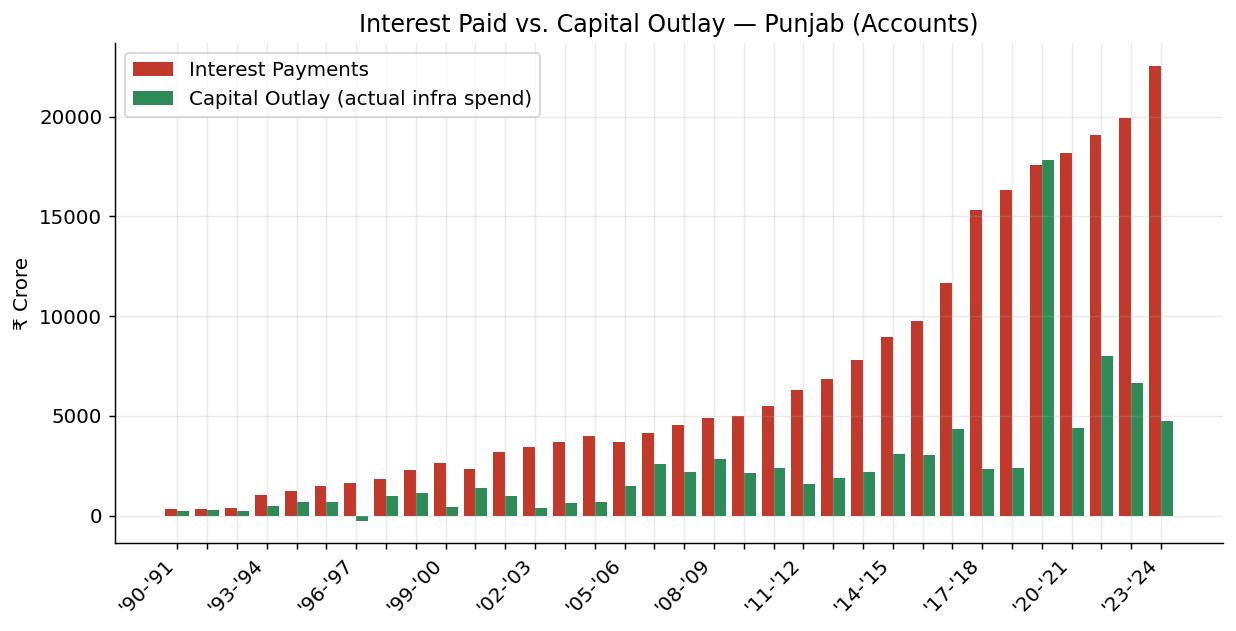

In [124]:
x = range(len(years))
w = 0.4

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar([i - w/2 for i in x], interest, width=w, label="Interest Payments", color=COLOR_C)
ax.bar([i + w/2 for i in x], capital_out, width=w, label="Capital Outlay (actual infra spend)", color=COLOR_D)
ax.set_title("Interest Paid vs. Capital Outlay — Punjab (Accounts)")
ax.set_ylabel("₹ Crore")
thin_xticks(ax, years_short, step=3)
ax.legend()

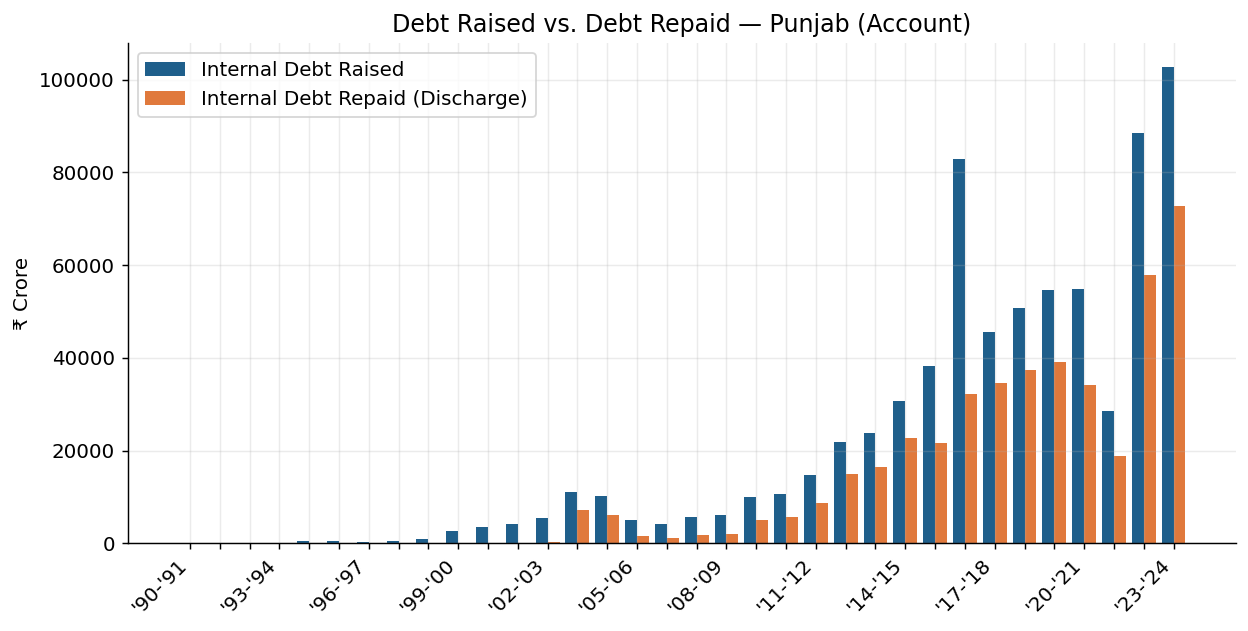

In [126]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar([i - w/2 for i in x], debt_raised, width=w, label="Internal Debt Raised", color=COLOR_A)
ax.bar([i + w/2 for i in x], discharge, width=w, label="Internal Debt Repaid (Discharge)", color=COLOR_B)
ax.set_title("Debt Raised vs. Debt Repaid — Punjab (Account)")
ax.set_ylabel("₹ Crore")
thin_xticks(ax, years_short, step=3)
ax.legend()

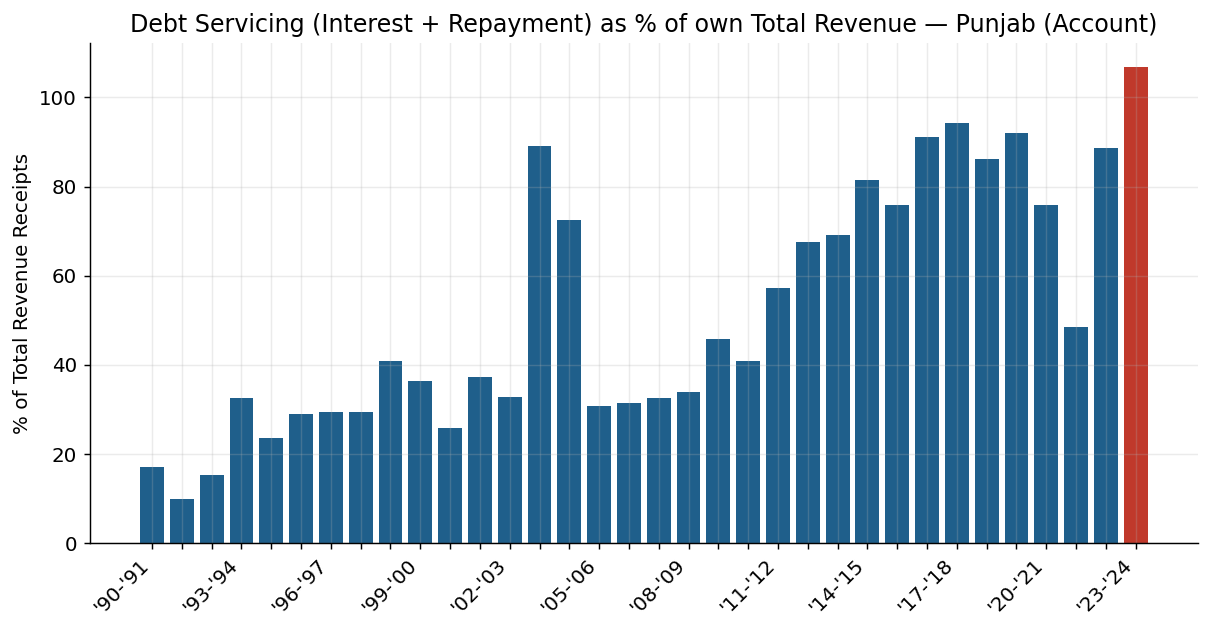

In [127]:
fig, ax = plt.subplots(figsize=(11, 5))
colors = [COLOR_C if v >= 100 else COLOR_A for v in debt_service_pct]
ax.bar(x, debt_service_pct, color=colors)
ax.set_title("Debt Servicing (Interest + Repayment) as % of own Total Revenue — Punjab (Account)")
ax.set_ylabel("% of Total Revenue Receipts")
thin_xticks(ax, years_short, step=3)

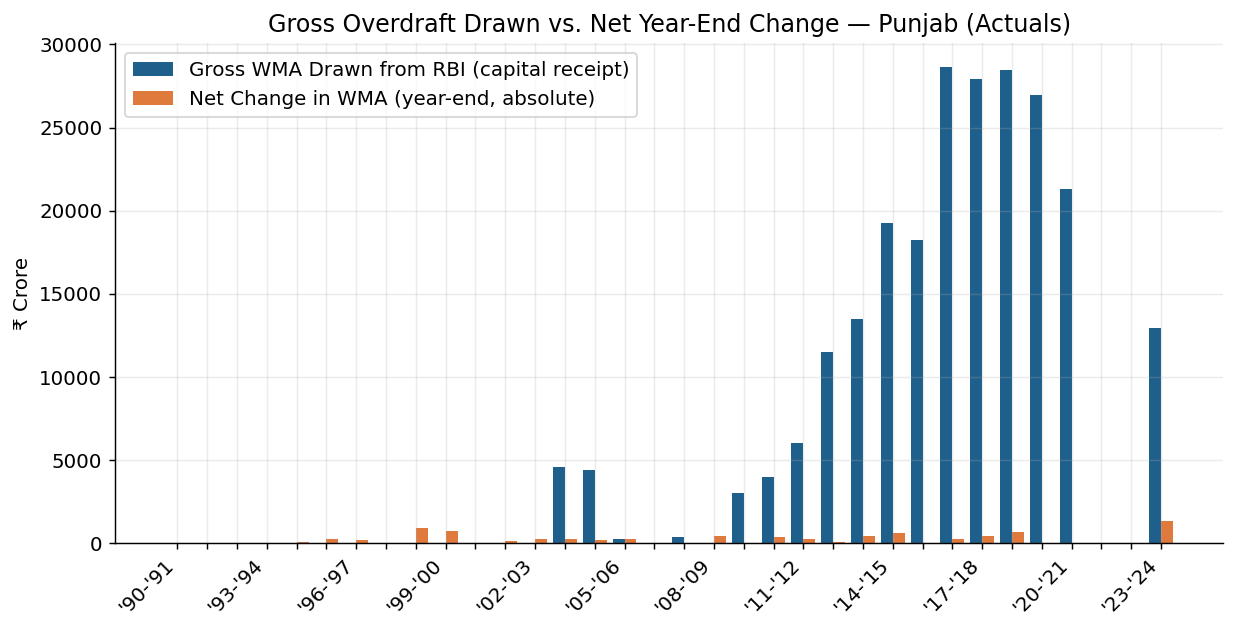

In [41]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar([i - w/2 for i in x], wma_gross, width=w, label="Gross WMA Drawn from RBI (capital receipt)", color=COLOR_A)
ax.bar([i + w/2 for i in x], wma_net.abs(), width=w, label="Net Change in WMA (year-end, absolute)", color=COLOR_B)
ax.set_title("Gross Overdraft Drawn vs. Net Year-End Change — Punjab (Actuals)")
ax.set_ylabel("₹ Crore")
thin_xticks(ax, years_short, step=3)
ax.legend()

/tmp/ipykernel_1156/454258832.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


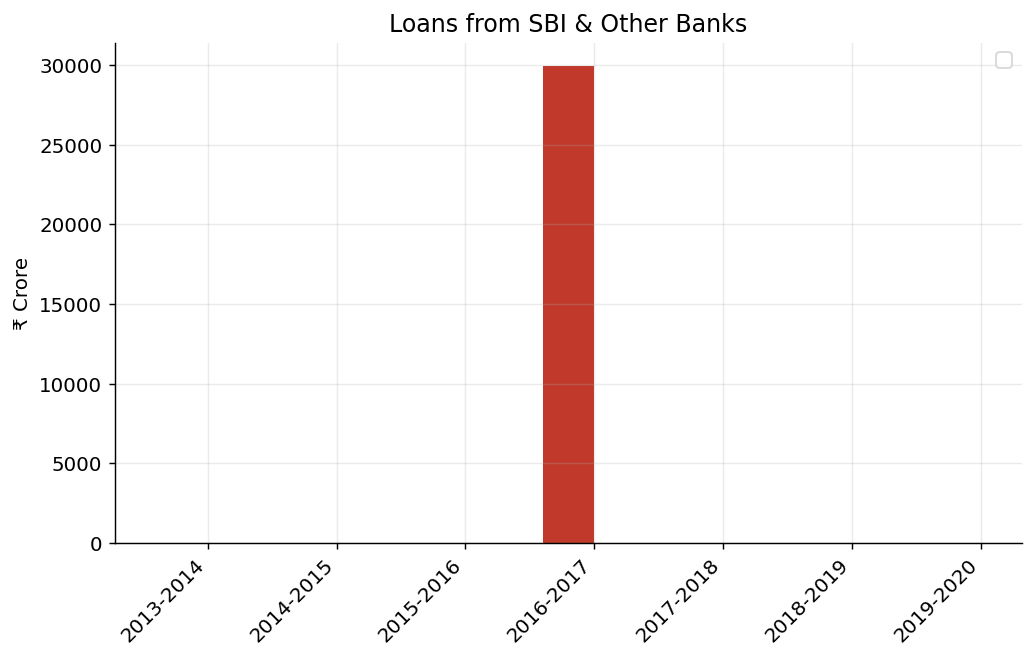

In [42]:
zoom_years = [y for y in years if "2013" <= y[:4] <= "2019"]
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar([i - w/2 for i in range(len(zoom_years))], sbi_loans.loc[zoom_years], width=w,
        color=COLOR_C)
ax.set_title("Loans from SBI & Other Banks")
ax.set_ylabel("₹ Crore")
ax.set_xticks(range(len(zoom_years)))
ax.set_xticklabels(zoom_years, rotation=45, ha="right")
ax.legend()

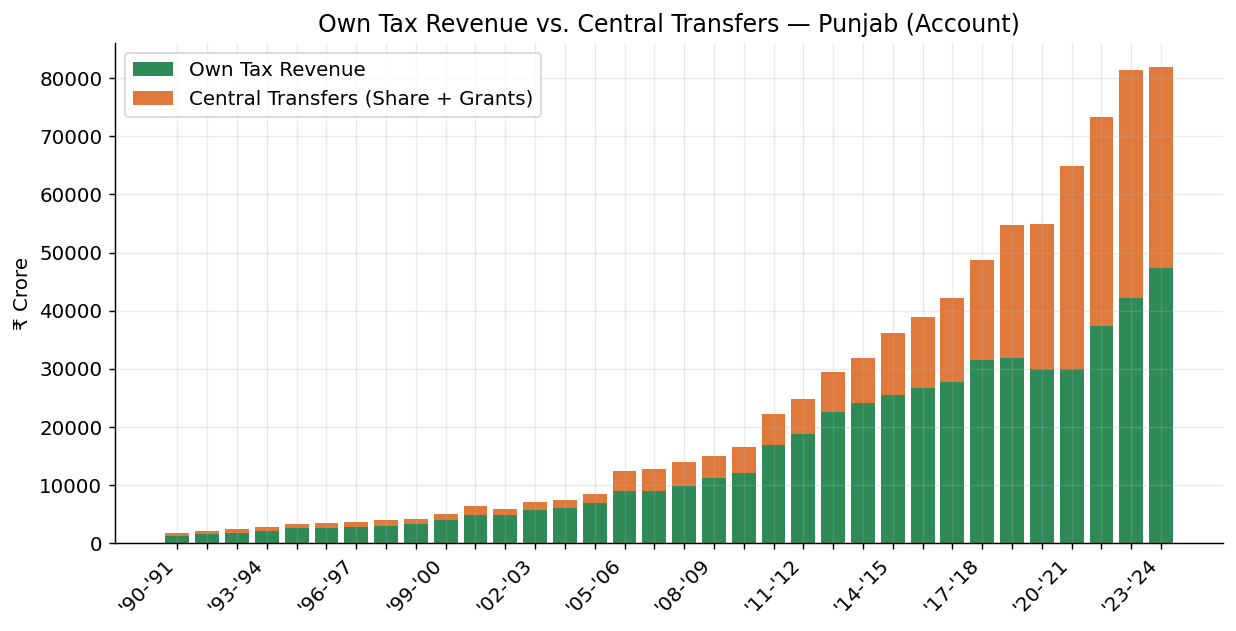

In [128]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x, own_tax, label="Own Tax Revenue", color=COLOR_D)
ax.bar(x, central_tax + grants, bottom=own_tax, label="Central Transfers (Share + Grants)", color=COLOR_B)
ax.set_title("Own Tax Revenue vs. Central Transfers — Punjab (Account)")
ax.set_ylabel("₹ Crore")
thin_xticks(ax, years_short, step=3)
ax.legend()

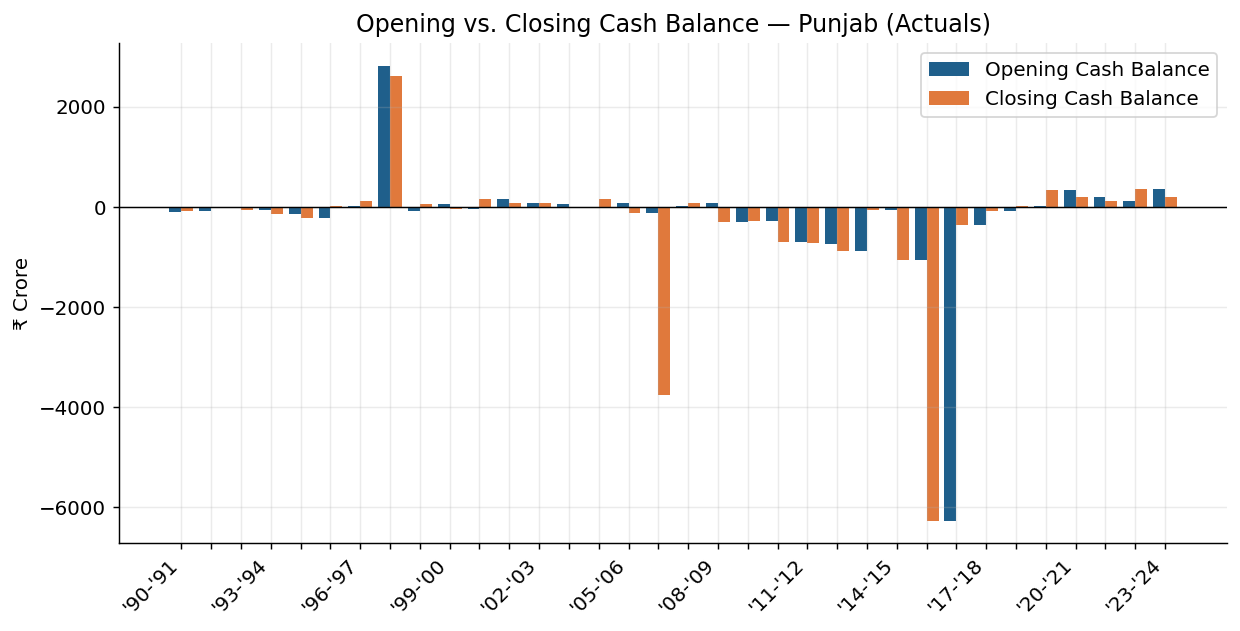

In [44]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar([i - w/2 for i in x], open_bal, width=w, label="Opening Cash Balance", color=COLOR_A)
ax.bar([i + w/2 for i in x], close_bal, width=w, label="Closing Cash Balance", color=COLOR_B)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Opening vs. Closing Cash Balance — Punjab (Actuals)")
ax.set_ylabel("₹ Crore")
thin_xticks(ax, years_short, step=3)
ax.legend()

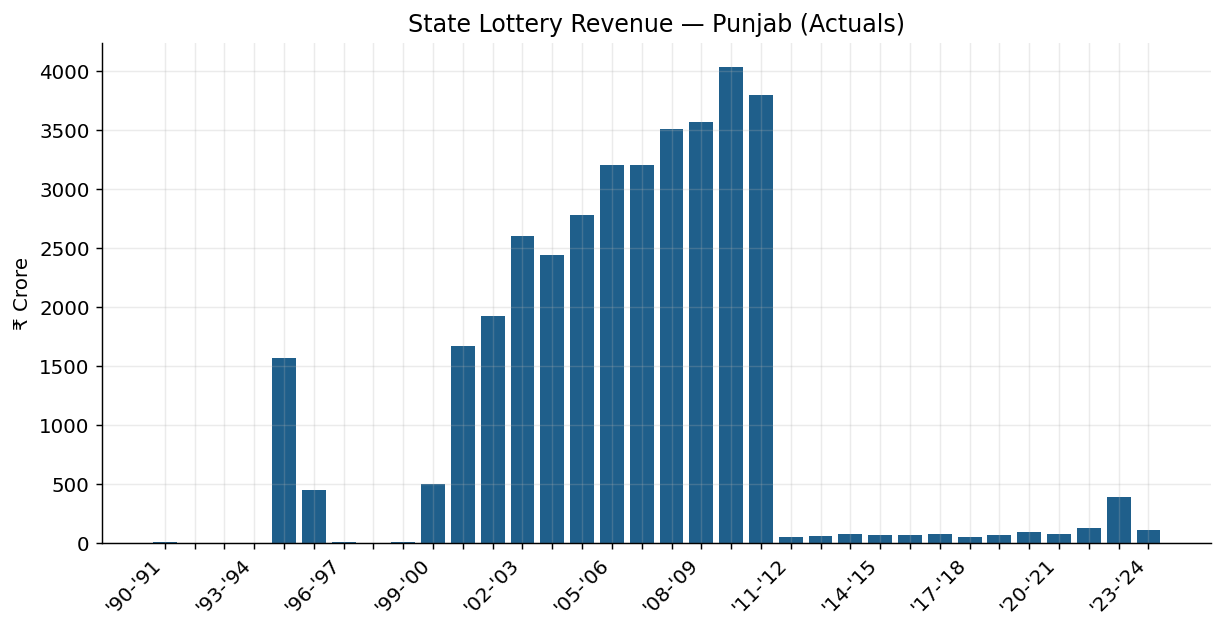

In [45]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x, lottery, color=COLOR_A)
ax.set_title("State Lottery Revenue — Punjab (Actuals)")
ax.set_ylabel("₹ Crore")
thin_xticks(ax, years_short, step=3)

[Text(0, 0, '2014-2015'),
 Text(1, 0, '2015-2016'),
 Text(2, 0, '2016-2017'),
 Text(3, 0, '2017-2018'),
 Text(4, 0, '2018-2019'),
 Text(5, 0, '2019-2020'),
 Text(6, 0, '2020-2021'),
 Text(7, 0, '2021-2022'),
 Text(8, 0, '2022-2023'),
 Text(9, 0, '2023-2024')]

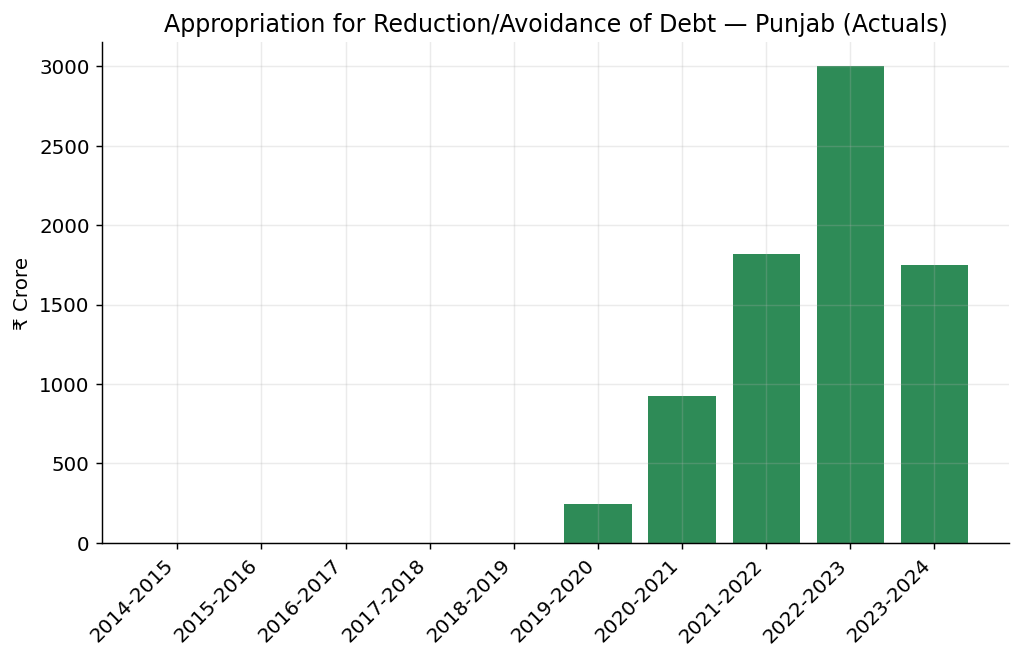

In [46]:
recent_years = [y for y in years if y[:4] >= "2014"]
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(range(len(recent_years)), sinking_fund.loc[recent_years], color=COLOR_D)
ax.set_title("Appropriation for Reduction/Avoidance of Debt — Punjab (Actuals)")
ax.set_ylabel("₹ Crore")
ax.set_xticks(range(len(recent_years)))
ax.set_xticklabels(recent_years, rotation=45, ha="right")

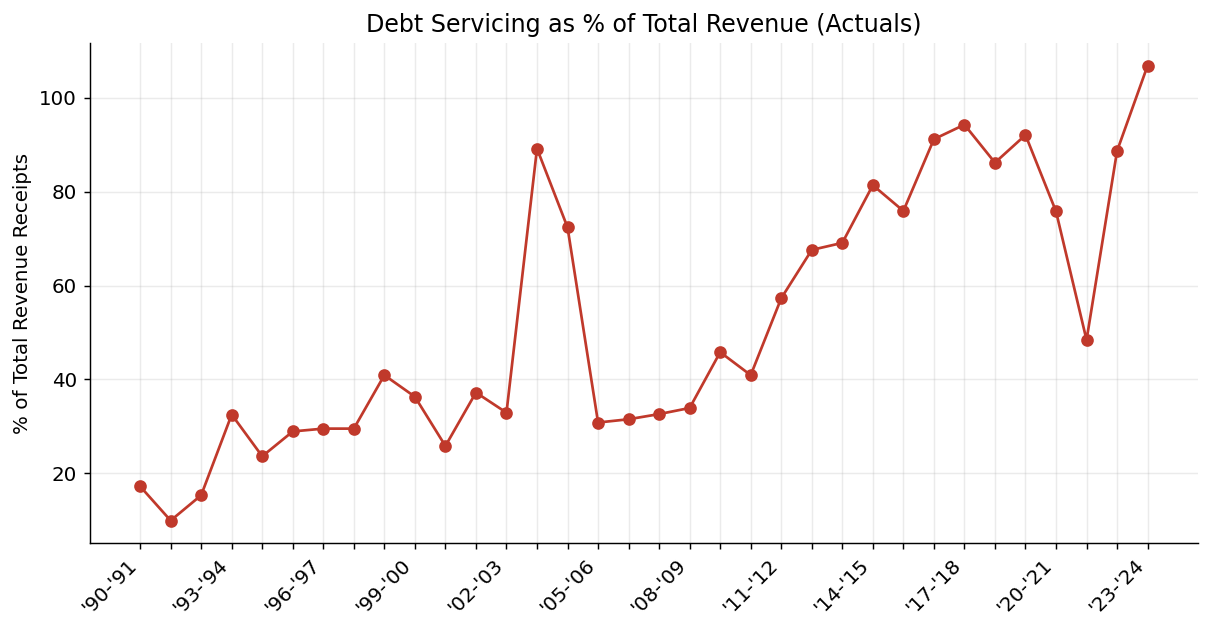

In [47]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(x, debt_service_pct, marker="o", color=COLOR_C)
ax.set_title("Debt Servicing as % of Total Revenue (Actuals)")
ax.set_ylabel("% of Total Revenue Receipts")
thin_xticks(ax, years_short, step=3)

[Text(0, 0, '2017-2018'),
 Text(1, 0, '2018-2019'),
 Text(2, 0, '2019-2020'),
 Text(3, 0, '2020-2021'),
 Text(4, 0, '2021-2022'),
 Text(5, 0, '2022-2023'),
 Text(6, 0, '2023-2024')]

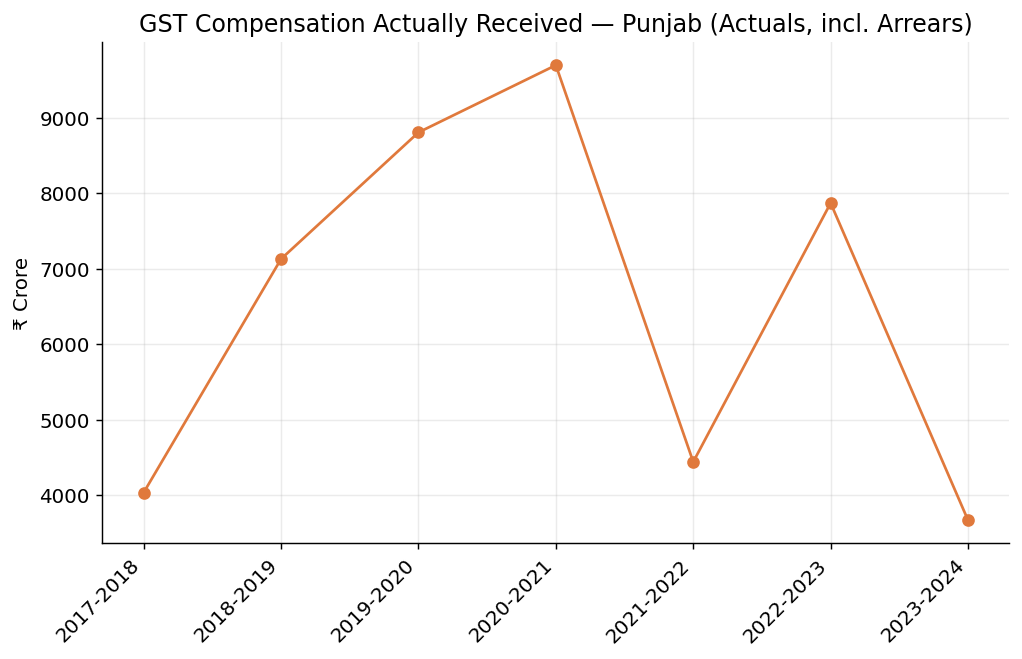

In [48]:
fig, ax = plt.subplots(figsize=(9, 5))
gst_years = [y for y in years if y[:4] >= "2017"]
ax.plot(range(len(gst_years)), gst_comp.loc[gst_years], marker="o", color=COLOR_B)
ax.set_title("GST Compensation Actually Received — Punjab (Actuals, incl. Arrears)")
ax.set_ylabel("₹ Crore")
ax.set_xticks(range(len(gst_years)))
ax.set_xticklabels(gst_years, rotation=45, ha="right")

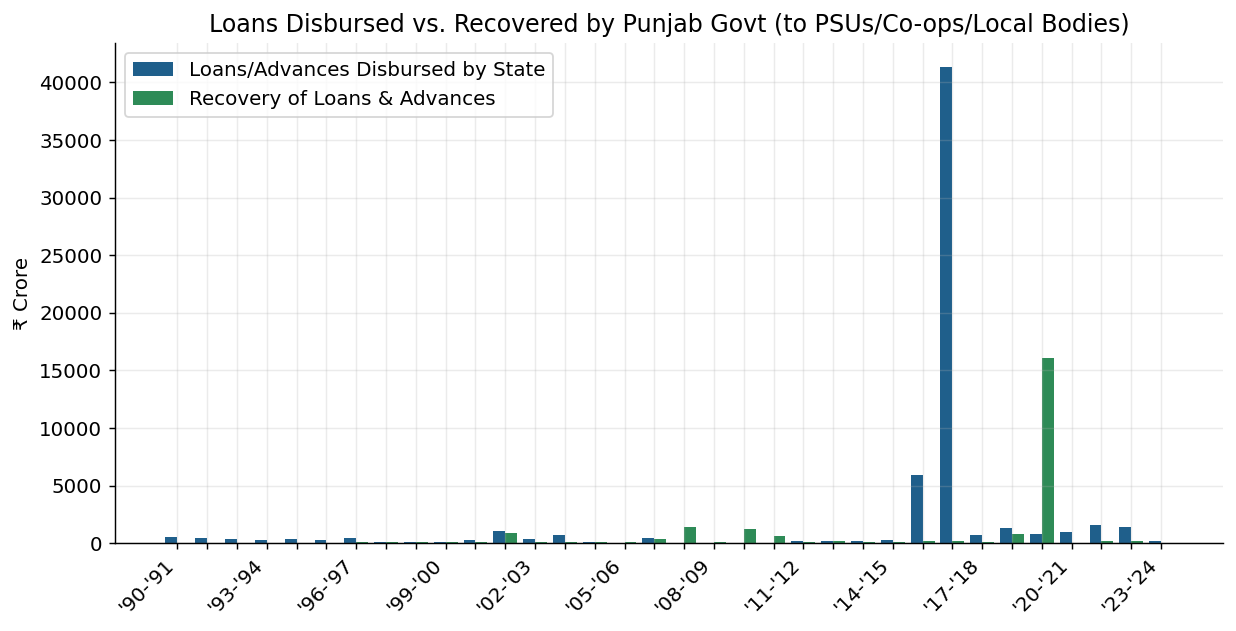

In [49]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar([i - w/2 for i in x], onlending, width=w, label="Loans/Advances Disbursed by State", color=COLOR_A)
ax.bar([i + w/2 for i in x], loan_recovery, width=w, label="Recovery of Loans & Advances", color=COLOR_D)
ax.set_title("Loans Disbursed vs. Recovered by Punjab Govt (to PSUs/Co-ops/Local Bodies)")
ax.set_ylabel("₹ Crore")
thin_xticks(ax, years_short, step=3)
ax.legend()

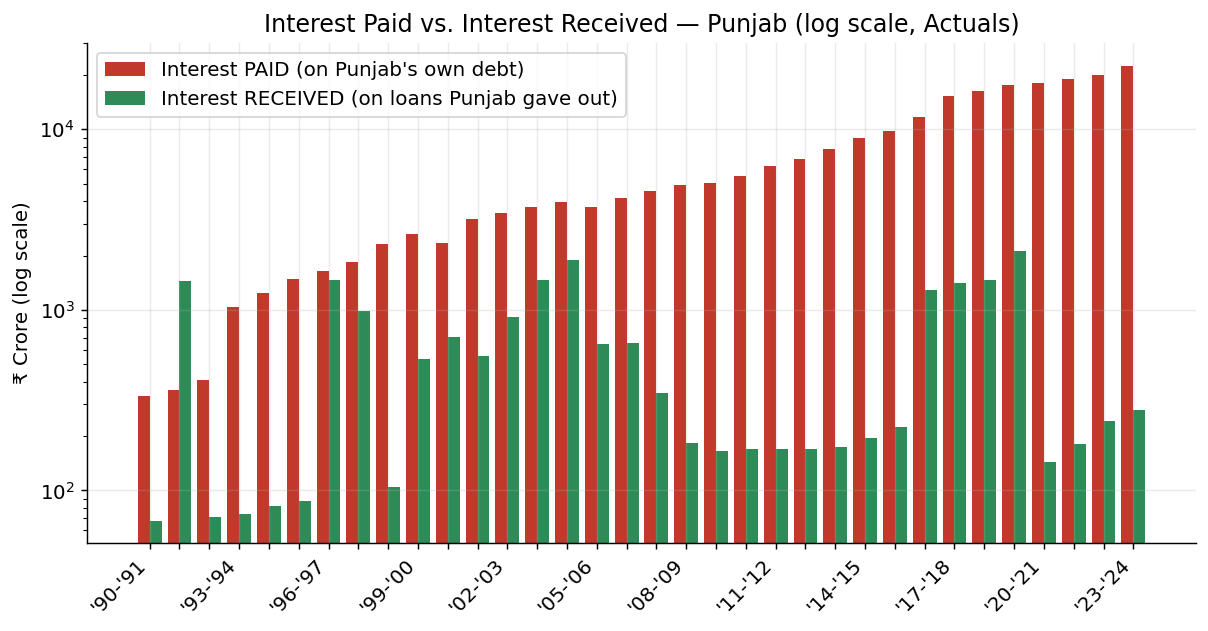

In [50]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar([i - w/2 for i in x], interest, width=w, label="Interest PAID (on Punjab's own debt)", color=COLOR_C)
ax.bar([i + w/2 for i in x], int_receipts, width=w, label="Interest RECEIVED (on loans Punjab gave out)", color=COLOR_D)
ax.set_yscale("log")
ax.set_title("Interest Paid vs. Interest Received — Punjab (log scale, Actuals)")
ax.set_ylabel("₹ Crore (log scale)")
thin_xticks(ax, years_short, step=3)
ax.legend()

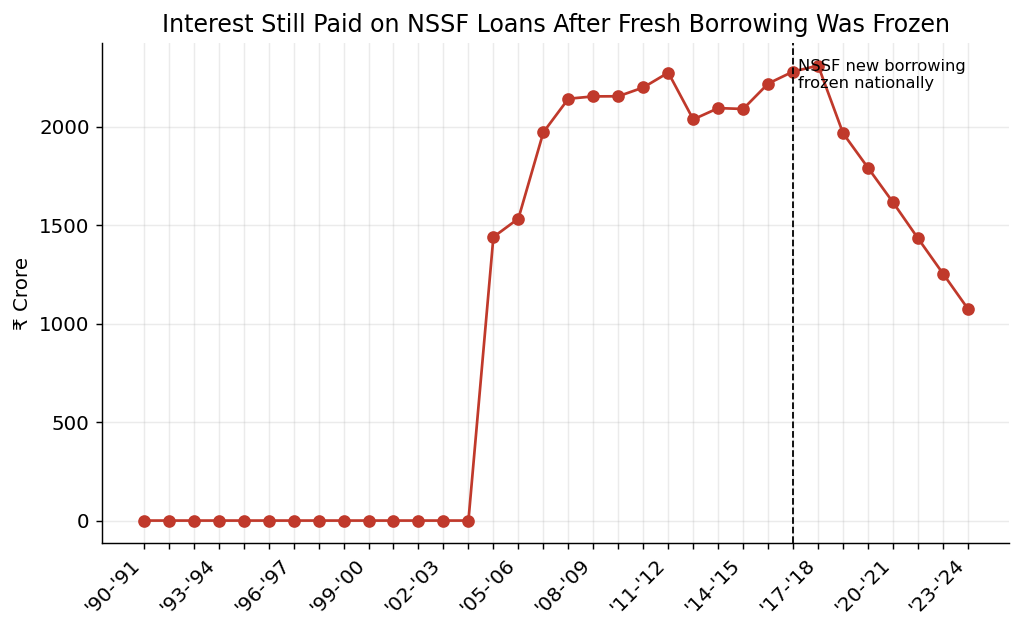

In [51]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(len(years)), nssf_interest, marker="o", color=COLOR_C)
freeze_idx = years.index("2016-2017")
ax.axvline(freeze_idx, color="black", linestyle="--", linewidth=1)
ax.text(freeze_idx + 0.2, max(nssf_interest) * 0.95, "NSSF new borrowing\nfrozen nationally", fontsize=9)
ax.set_title("Interest Still Paid on NSSF Loans After Fresh Borrowing Was Frozen")
ax.set_ylabel("₹ Crore")
thin_xticks(ax, years_short, step=3)

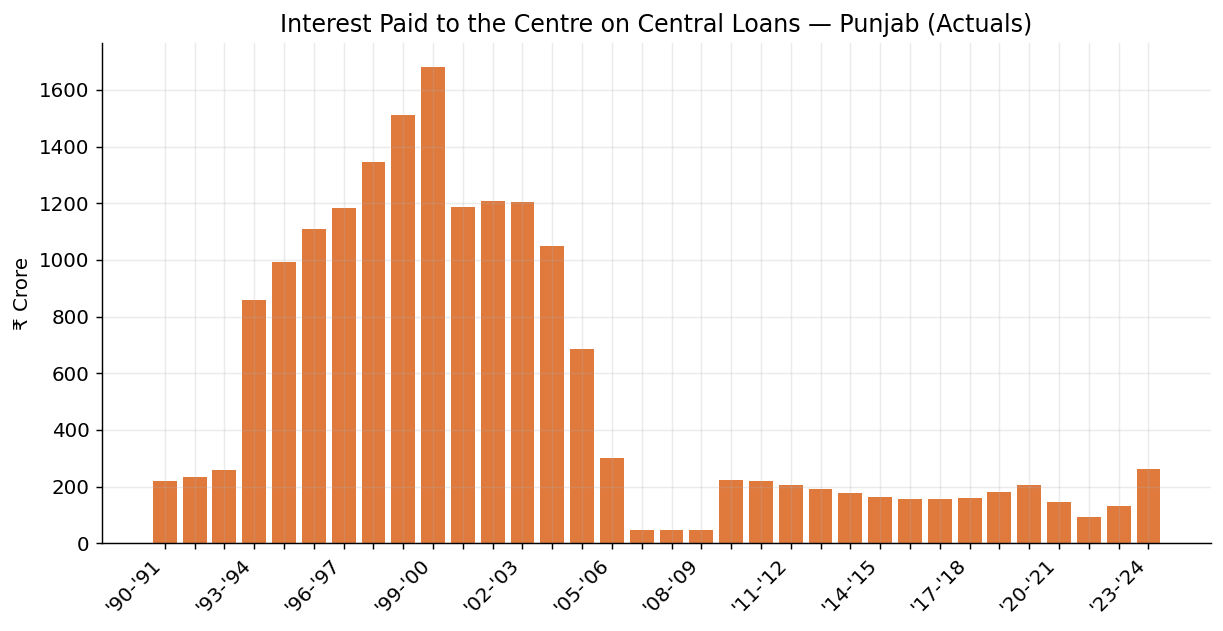

In [52]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x, int_to_centre, color=COLOR_B)
ax.set_title("Interest Paid to the Centre on Central Loans — Punjab (Actuals)")
ax.set_ylabel("₹ Crore")
thin_xticks(ax, years_short, step=3)

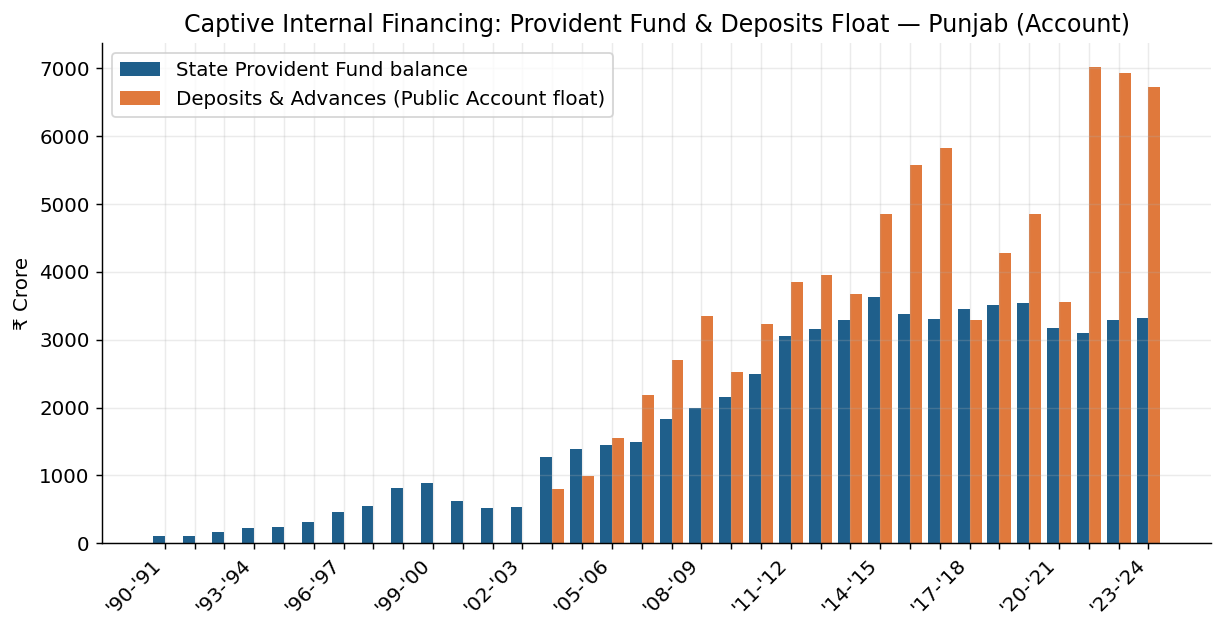

In [129]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar([i - w/2 for i in x], prov_fund, width=w, label="State Provident Fund balance", color=COLOR_A)
ax.bar([i + w/2 for i in x], deposits_adv, width=w, label="Deposits & Advances (Public Account float)", color=COLOR_B)
ax.set_title("Captive Internal Financing: Provident Fund & Deposits Float — Punjab (Account)")
ax.set_ylabel("₹ Crore")
thin_xticks(ax, years_short, step=3)
ax.legend()

In [54]:
summary = pd.DataFrame({
    "Total Revenue": revenue,
    "Total Expenditure": expenditure,
    "Interest Payments": interest,
    "Capital Outlay": capital_out,
    "Interest / Capital Outlay (x)": (interest / capital_out).round(2),
    "Debt Raised": debt_raised,
    "Debt Repaid": discharge,
    "Debt Service (Int+Repay)": debt_service,
    "Debt Service % of Revenue": debt_service_pct,
    "Revenue Deficit": rev_deficit,
    "Central Dependency %": central_dependency,
    "Opening Cash Balance": open_bal,
    "Closing Cash Balance": close_bal,
    "Gross WMA Drawn": wma_gross,
    "Net WMA Change": wma_net,
    "Sinking Fund Provision": sinking_fund,
    "Loans Disbursed by State": onlending,
    "Loans Recovered by State": loan_recovery,
    "Interest Received": int_receipts,
    "Interest Paid to Centre": int_to_centre,
    "Interest on NSSF": nssf_interest,
    "State Provident Fund Balance": prov_fund,
    "Deposits & Advances Float": deposits_adv,
})
summary.round(1).to_csv(os.path.join(OUT_TABLES, "punjab_full_summary.csv"))

headline = summary.loc[["1990-1991", "2000-2001", "2010-2011", "2016-2017",
                         "2020-2021", "2022-2023", "2023-2024"]]
headline.round(1).to_csv(os.path.join(OUT_TABLES, "punjab_headline_years.csv"))

In [55]:
NATIONAL_HEADS = [
    "Total: TOTAL REVENUE (I+II)",
    "Total: TOTAL EXPENDITURE (I+II+III)",
    "II.C.2: Interest Payments (i to iv)",
    "II: Discharge of Internal Debt (1 to 8)",
    "I: Total Capital Outlay (1 + 2)",
    "I.A: State's Own Tax Revenue (1 to 3)",
    "I.B: Share in Central Taxes (i to ix)",
    "II.D: Grants from the Centre (1 to 7)",
    "A: Surplus (+)/Deficit (-) on Revenue Account",
]


def load_all_states(path):
    df = pd.read_excel(path, sheet_name="Data")
    sub = df[df["Budget Head"].isin(NATIONAL_HEADS)][["State/UT", "Budget Head", "Fiscal Year", "Account"]]
    return sub


def year_pivot(sub_df, year, exclude_aggregate=True):
    d = sub_df[sub_df["Fiscal Year"] == year]
    state_piv = d.pivot_table(index="State/UT", columns="Budget Head", values="Account", aggfunc="first")
    if exclude_aggregate:
        state_piv = state_piv[state_piv.index != "All States/UT"]
    return state_piv


def metrics_for_year(state_piv):
    rev = state_piv["Total: TOTAL REVENUE (I+II)"]
    exp = state_piv["Total: TOTAL EXPENDITURE (I+II+III)"]
    interest_ = state_piv["II.C.2: Interest Payments (i to iv)"]
    discharge_ = state_piv["II: Discharge of Internal Debt (1 to 8)"]
    capout = state_piv["I: Total Capital Outlay (1 + 2)"]
    owntax = state_piv["I.A: State's Own Tax Revenue (1 to 3)"]
    centraltax = state_piv["I.B: Share in Central Taxes (i to ix)"]
    grants_ = state_piv["II.D: Grants from the Centre (1 to 7)"]
    revdef = state_piv["A: Surplus (+)/Deficit (-) on Revenue Account"]

    return pd.DataFrame({
        "Revenue": rev,
        "DebtService_pct_Revenue": ((interest_ + discharge_) / rev * 100).round(1),
        "Interest_pct_Revenue": (interest_ / rev * 100).round(1),
        "Interest_to_CapOutlay": (interest_ / capout).round(2),
        "CapOutlay_pct_Expenditure": (capout / exp * 100).round(1),
        "OwnTax_pct_Revenue": (owntax / rev * 100).round(1),
        "CentralDependency_pct": ((centraltax + grants_) / rev * 100).round(1),
        "RevDeficit_pct_Revenue": (revdef / rev * 100).round(1),
    })


all_states_sub = load_all_states(INPUT_FILE)
LATEST_YEAR = "2023-2024"
latest = metrics_for_year(year_pivot(all_states_sub, LATEST_YEAR))
latest.to_csv(os.path.join(OUT_TABLES, "all_states_2023_24.csv"))


def ranked_bar(series, title, ylabel, ascending, filename, pct_line=None, top_n=None):
    s = series.dropna().sort_values(ascending=ascending)
    if top_n:
        s = s.head(top_n)
    colors = [COLOR_PUNJAB if state == "Punjab" else COLOR_OTHER for state in s.index]
    fig, ax = plt.subplots(figsize=(12, 5.5))
    ax.bar(range(len(s)), s.values, color=colors)
    ax.set_xticks(range(len(s)))
    ax.set_xticklabels(s.index, rotation=60, ha="right", fontsize=8)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    if pct_line is not None:
        ax.axhline(pct_line, color="black", linestyle="--", linewidth=1)
    savefig(fig, filename)

In [103]:
ranked_bar(latest["DebtService_pct_Revenue"],
           f"Debt Servicing as % of Total Revenue — All Indian States ({LATEST_YEAR}, Account)",
           "% of Total Revenue", ascending=False, filename="17_national_debt_service_ranking.png")

saved: output/charts/17_national_debt_service_ranking.png


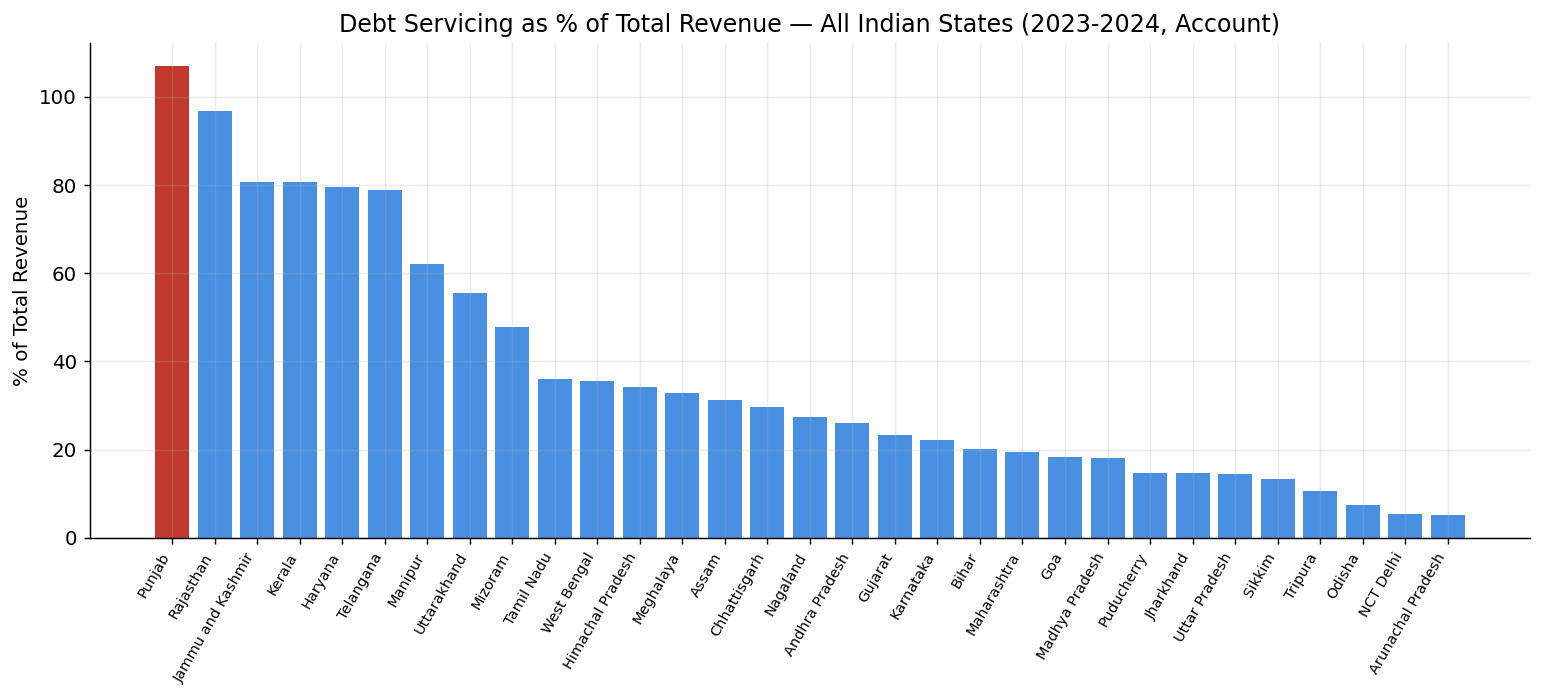

In [104]:
from IPython.display import Image
Image('output/charts/17_national_debt_service_ranking.png')

In [105]:
ranked_bar(latest["Interest_to_CapOutlay"],
           f"Interest Paid ÷ Capital Outlay — All Indian States ({LATEST_YEAR}, Accounts)",
           "Interest / Capital Outlay (x)", ascending=False, filename="18_national_interest_capex_ranking.png")

saved: output/charts/18_national_interest_capex_ranking.png


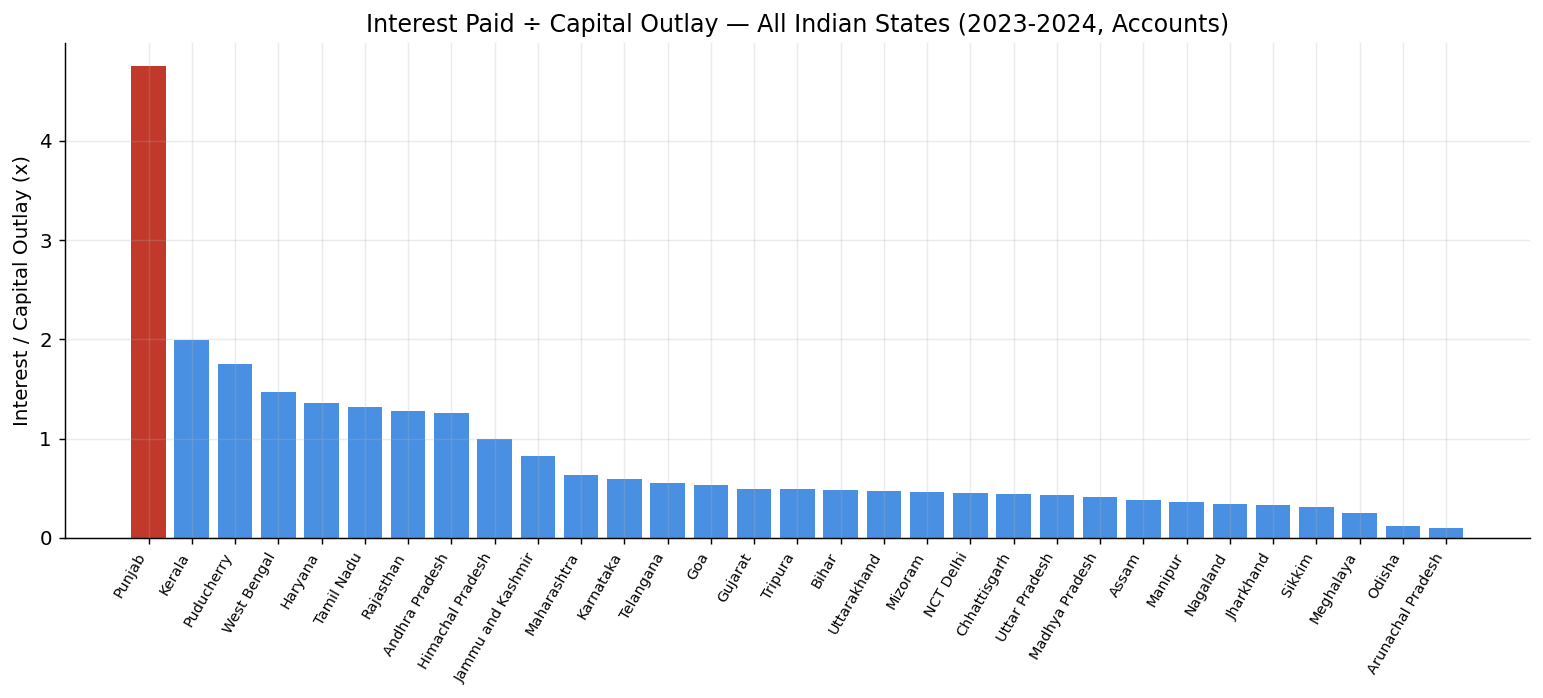

In [106]:
from IPython.display import Image
Image('output/charts/18_national_interest_capex_ranking.png')

In [107]:
ranked_bar(latest["CapOutlay_pct_Expenditure"],
           f"Capital Outlay as % of Total Expenditure — All Indian States ({LATEST_YEAR}, Account)",
           "% of Total Expenditure", ascending=True, filename="19_national_capex_share_ranking.png")

saved: output/charts/19_national_capex_share_ranking.png


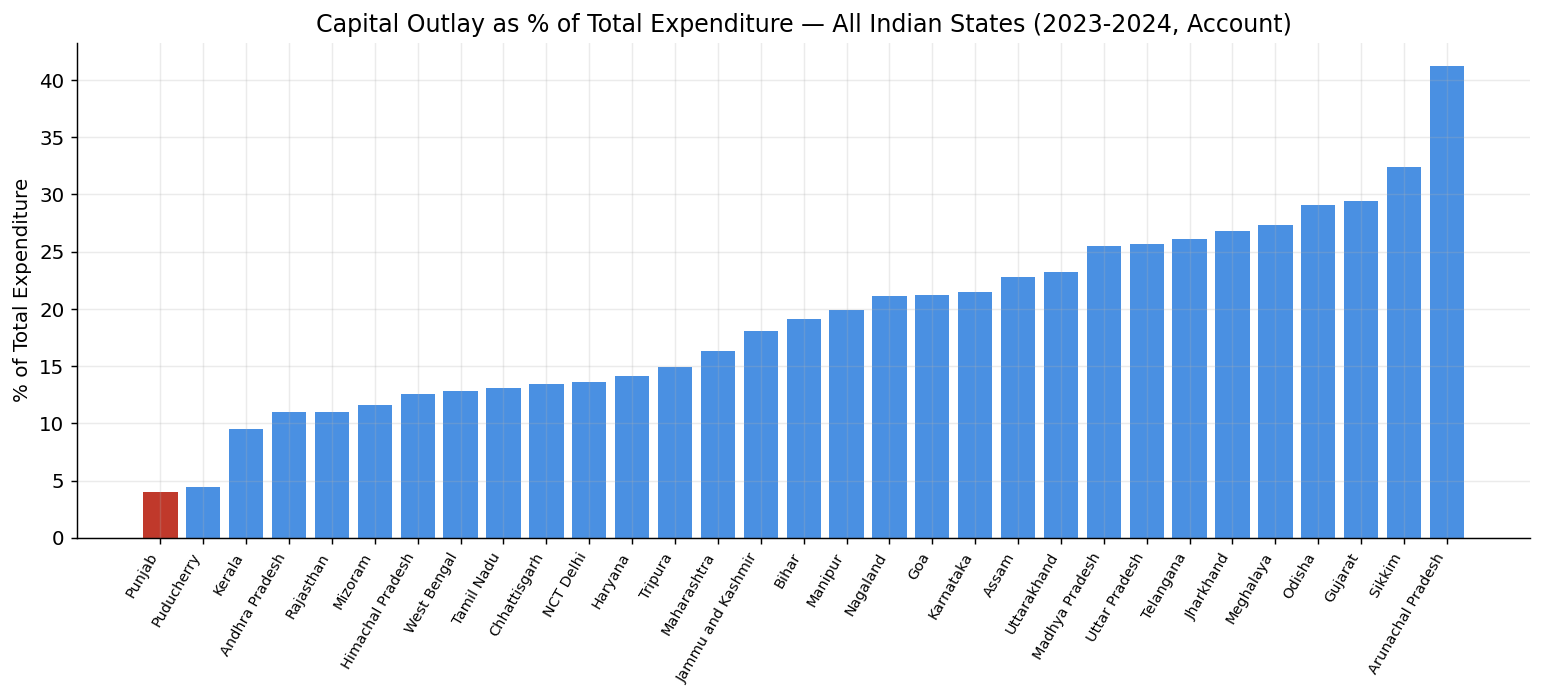

In [108]:
from IPython.display import Image
Image('output/charts/19_national_capex_share_ranking.png')

In [109]:
ranked_bar(latest["RevDeficit_pct_Revenue"],
           f"Revenue deficit as a % of total evenue receipts — All Indian States ({LATEST_YEAR}, Account)",
           "% of total Revenue (negative = deficit)", ascending=True, filename="20_national_revdeficit_ranking.png")

saved: output/charts/20_national_revdeficit_ranking.png


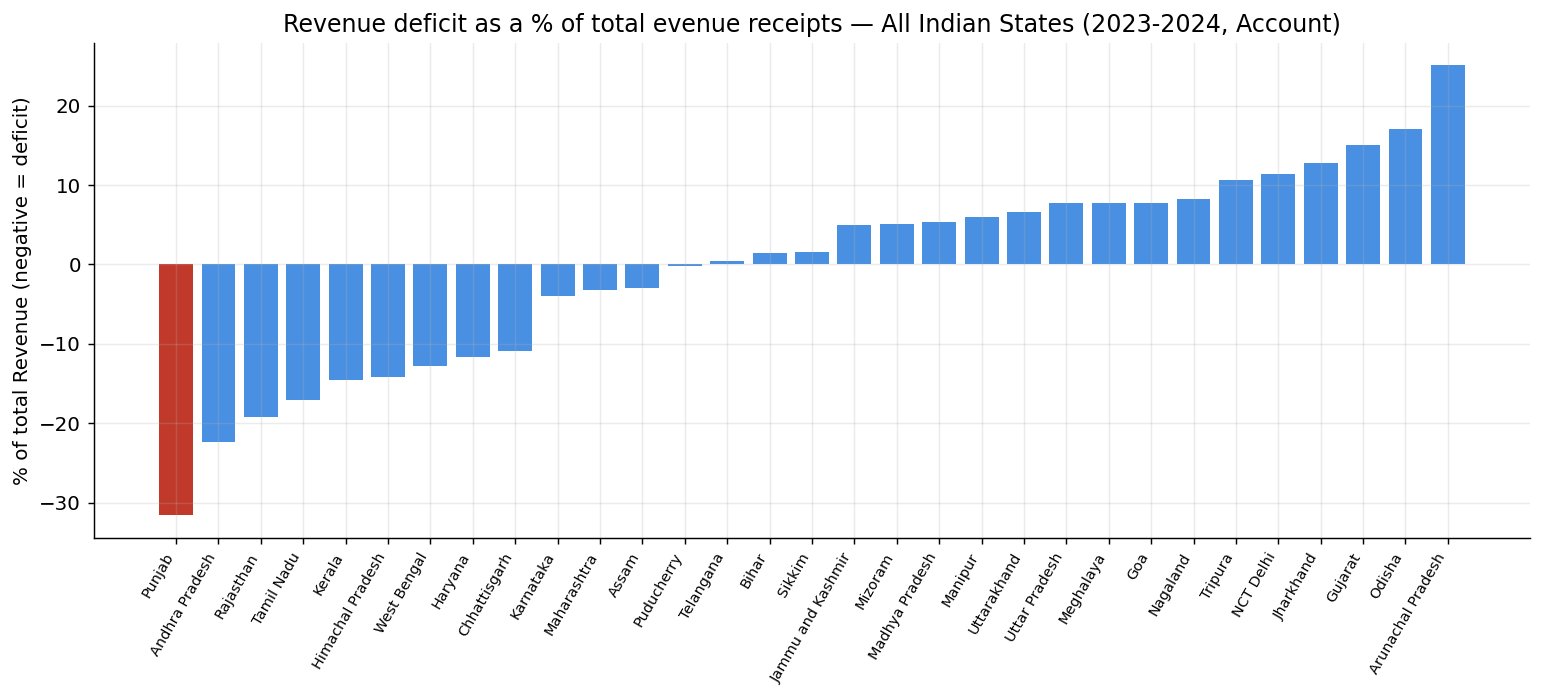

In [110]:
from IPython.display import Image
Image('output/charts/20_national_revdeficit_ranking.png')

In [64]:
ranked_bar(latest["Interest_pct_Revenue"],
           f"Interest Payments as % of Revenue — All States ({LATEST_YEAR})",
           "% of Revenue", ascending=False, filename="21_national_interest_pct_revenue_ranking.png")

saved: output/charts/21_national_interest_pct_revenue_ranking.png


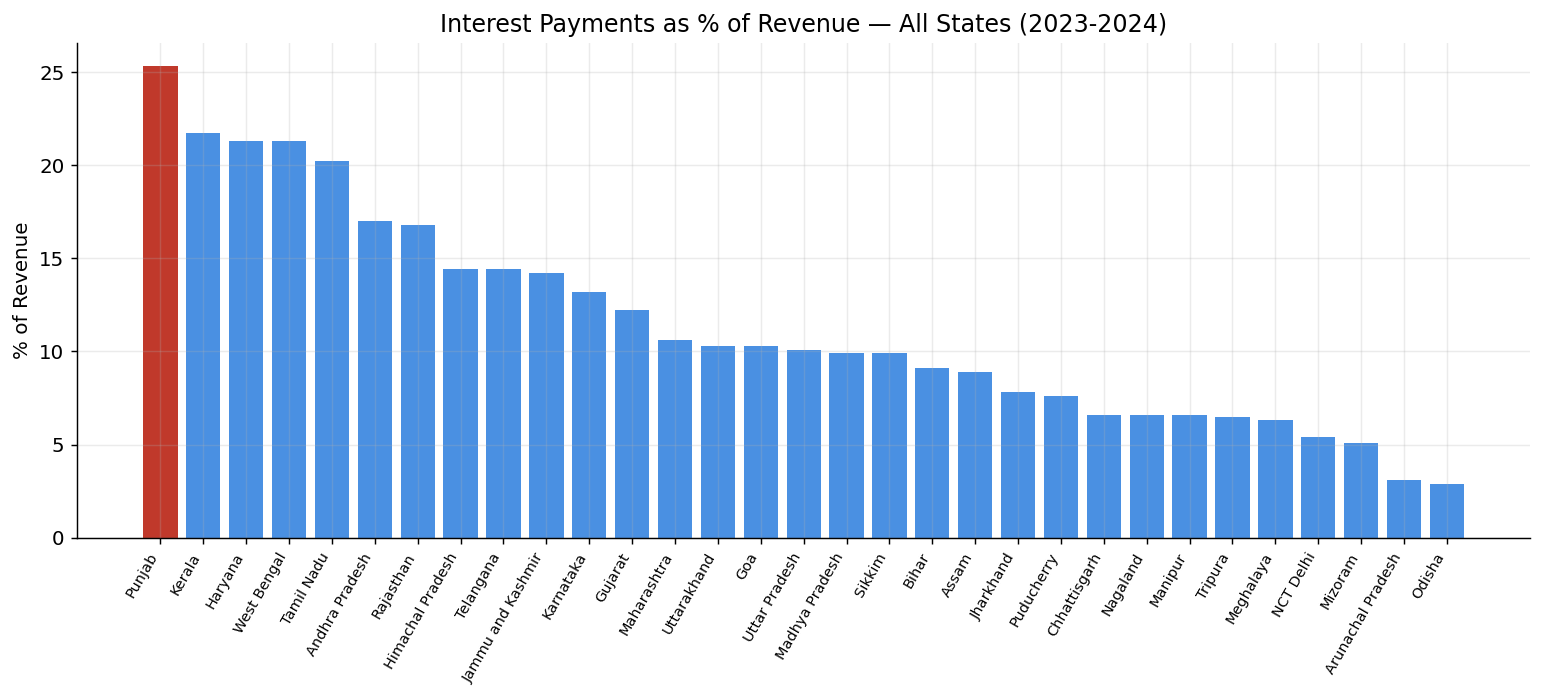

In [65]:
from IPython.display import Image
Image('output/charts/21_national_interest_pct_revenue_ranking.png')

[Text(0, 0, '1990-1991'),
 Text(1, 0, ''),
 Text(2, 0, '1992-1993'),
 Text(3, 0, ''),
 Text(4, 0, '1994-1995'),
 Text(5, 0, ''),
 Text(6, 0, '1996-1997'),
 Text(7, 0, ''),
 Text(8, 0, '1998-1999'),
 Text(9, 0, ''),
 Text(10, 0, '2000-2001'),
 Text(11, 0, ''),
 Text(12, 0, '2002-2003'),
 Text(13, 0, ''),
 Text(14, 0, '2004-2005'),
 Text(15, 0, ''),
 Text(16, 0, '2006-2007'),
 Text(17, 0, ''),
 Text(18, 0, '2008-2009'),
 Text(19, 0, ''),
 Text(20, 0, '2010-2011'),
 Text(21, 0, ''),
 Text(22, 0, '2012-2013'),
 Text(23, 0, ''),
 Text(24, 0, '2014-2015'),
 Text(25, 0, ''),
 Text(26, 0, '2016-2017'),
 Text(27, 0, ''),
 Text(28, 0, '2018-2019'),
 Text(29, 0, ''),
 Text(30, 0, '2020-2021'),
 Text(31, 0, ''),
 Text(32, 0, '2022-2023'),
 Text(33, 0, '')]

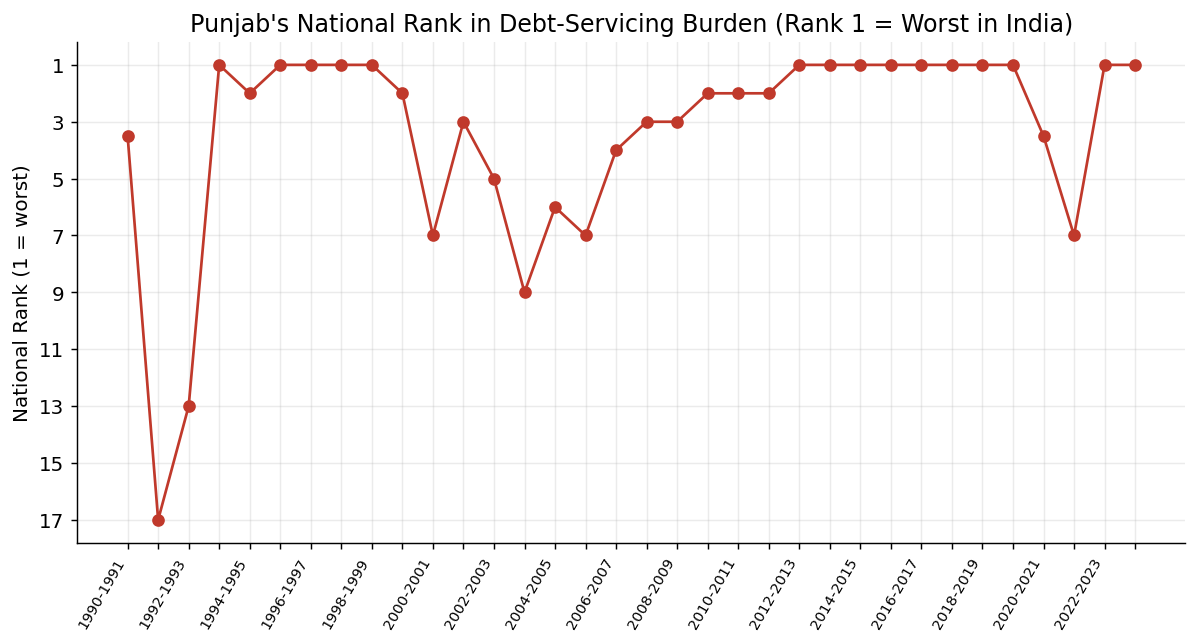

In [66]:
years = [f"{y}-{y+1}" for y in range(1990, 2024)]
rank_series = {}
for Y in years:
    piv = year_pivot(all_states_sub, Y)
    if "Total: TOTAL REVENUE (I+II)" not in piv.columns:
        continue
    m = metrics_for_year(piv)
    ds = m["DebtService_pct_Revenue"].dropna()
    if "Punjab" in ds.index:
        rank = ds.rank(ascending=False)["Punjab"]
        rank_series[Y] = rank

fig, ax = plt.subplots(figsize=(11, 5))
yrs = list(rank_series.keys())
vals = list(rank_series.values())
ax.plot(range(len(yrs)), vals, marker="o", color=COLOR_PUNJAB)
ax.invert_yaxis()  # rank 1 (worst) at top
ax.set_yticks(range(1, int(max(vals)) + 2, 2))
ax.set_title("Punjab's National Rank in Debt-Servicing Burden (Rank 1 = Worst in India)")
ax.set_ylabel("National Rank (1 = worst)")
ax.set_xticks(range(len(yrs)))
ax.set_xticklabels([y if i % 2 == 0 else "" for i, y in enumerate(yrs)], rotation=60, ha="right", fontsize=8)

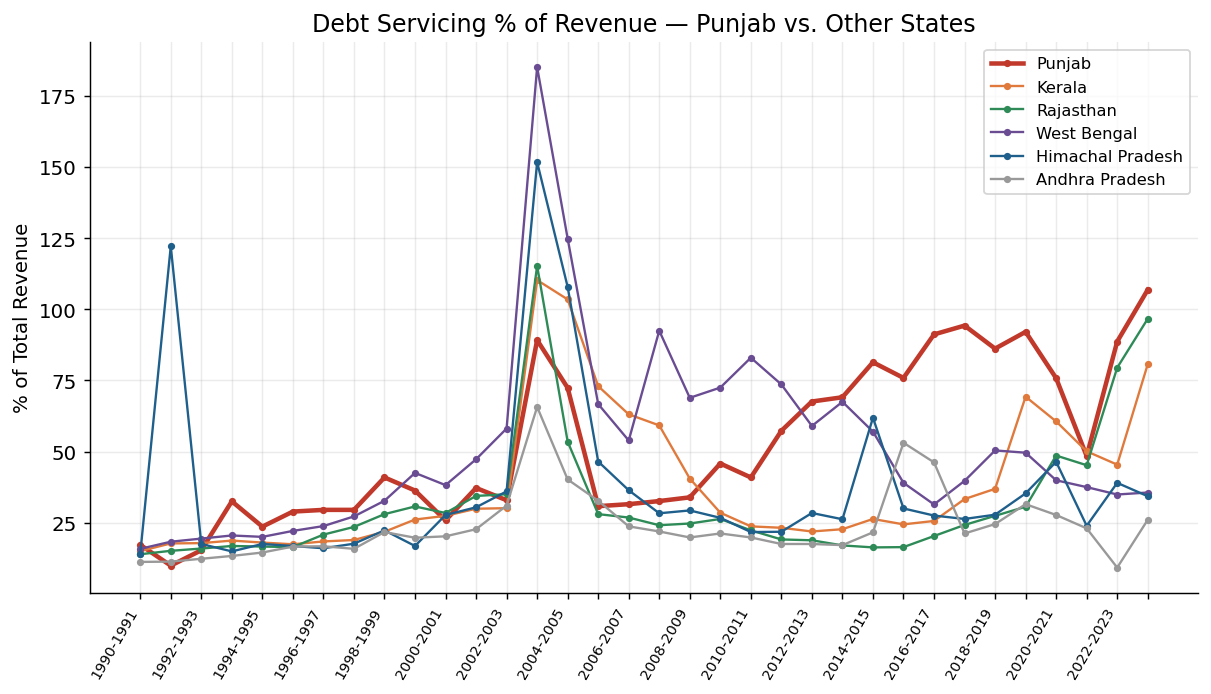

In [67]:
peers = ["Punjab", "Kerala", "Rajasthan", "West Bengal", "Himachal Pradesh", "Andhra Pradesh"]
peer_years = [f"{y}-{y+1}" for y in range(1990, 2024)]
rows = []
for Y in peer_years:
    piv = year_pivot(all_states_sub, Y)
    if "Total: TOTAL REVENUE (I+II)" not in piv.columns:
        continue
    m = metrics_for_year(piv)
    for p in peers:
        if p in m.index and pd.notna(m.loc[p, "DebtService_pct_Revenue"]):
            rows.append({"Year": Y, "State": p, "DebtService_pct": m.loc[p, "DebtService_pct_Revenue"]})
peer_df = pd.DataFrame(rows)
peer_pivot = peer_df.pivot(index="Year", columns="State", values="DebtService_pct")
peer_pivot.to_csv(os.path.join(OUT_TABLES, "peer_states_debt_service_trend.csv"))

fig, ax = plt.subplots(figsize=(11, 5.5))
for p in peers:
    if p in peer_pivot.columns:
        ax.plot(range(len(peer_pivot)), peer_pivot[p], marker="o", markersize=3,
                label=p, color=COLOR_PEER.get(p, "#888888"),
                linewidth=2.5 if p == "Punjab" else 1.3)
ax.set_title("Debt Servicing % of Revenue — Punjab vs. Other States")
ax.set_ylabel("% of Total Revenue")
ax.set_xticks(range(len(peer_pivot)))
ax.set_xticklabels([y if i % 2 == 0 else "" for i, y in enumerate(peer_pivot.index)], rotation=60, ha="right", fontsize=8)
ax.legend(fontsize=9)

In [68]:
# Summary printout
print("\n--- Punjab's national position in", LATEST_YEAR, "---")
for col in ["DebtService_pct_Revenue", "Interest_to_CapOutlay", "CapOutlay_pct_Expenditure", "RevDeficit_pct_Revenue"]:
    asc = col == "CapOutlay_pct_Expenditure" or col == "RevDeficit_pct_Revenue"
    r = latest[col].dropna().rank(ascending=asc)["Punjab"]
    n = latest[col].dropna().shape[0]
    print(f"{col}: Punjab value = {latest.loc['Punjab', col]}, rank {int(r)} of {n} (1=worst)")

print("\nDone. Charts in:", OUT_CHARTS, " Tables in:", OUT_TABLES)


--- Punjab's national position in 2023-2024 ---
DebtService_pct_Revenue: Punjab value = 106.9, rank 1 of 31 (1=worst)
Interest_to_CapOutlay: Punjab value = 4.75, rank 1 of 31 (1=worst)
CapOutlay_pct_Expenditure: Punjab value = 4.0, rank 1 of 31 (1=worst)
RevDeficit_pct_Revenue: Punjab value = -31.6, rank 1 of 31 (1=worst)

Done. Charts in: output/charts  Tables in: output/tables


In [69]:
import pandas as pd
from IPython.display import display

print("=== Punjab Full Summary (all years) ===")
display(pd.read_csv("output/tables/punjab_full_summary.csv", index_col=0))

=== Punjab Full Summary (all years) ===


,Total Revenue,Total Expenditure,Interest Payments,Capital Outlay,Interest / Capital Outlay (x),Debt Raised,Debt Repaid,Debt Service (Int+Repay),Debt Service % of Revenue,Revenue Deficit,...,Gross WMA Drawn,Net WMA Change,Sinking Fund Provision,Loans Disbursed by State,Loans Recovered by State,Interest Received,Interest Paid to Centre,Interest on NSSF,State Provident Fund Balance,Deposits & Advances Float
Fiscal Year,,,,,,,,,,,,,,,,,,,,,
1990-1991,1975.7,2519.9,332.2,218.4,1.5,43.3,8.4,340.6,17.2,-544.2,...,0.0,0.0,0.0,521.7,42.1,68.0,220.5,0.0,111.8,0.0
1991-1992,3715.8,4196.7,360.6,291.6,1.2,45.8,7.7,368.3,9.9,-480.9,...,0.0,0.0,0.0,419.4,41.4,1443.8,234.2,0.0,115.1,0.0
1992-1993,2786.9,3422.5,410.6,259.1,1.6,55.5,16.9,427.5,15.3,-635.6,...,0.0,0.0,0.0,401.7,44.4,71.3,259.5,0.0,167.0,0.0
1993-1994,3276.6,4043.6,1042.2,495.4,2.1,57.6,21.7,1063.9,32.5,-766.9,...,0.0,0.0,0.0,296.2,65.0,74.0,857.2,0.0,223.4,0.0
1994-1995,5300.9,6042.8,1243.7,711.4,1.8,515.2,8.8,1252.5,23.6,-741.8,...,0.0,-69.6,0.0,378.5,46.6,81.5,991.7,0.0,242.4,0.0
1995-1996,5184.8,5635.0,1489.6,679.2,2.2,502.6,9.3,1498.9,28.9,-450.2,...,0.0,-260.1,0.0,289.1,53.8,87.0,1108.8,0.0,307.6,0.0
1996-1997,5568.6,6925.7,1634.4,-238.8,-6.8,287.2,10.4,1644.8,29.5,-1357.1,...,0.0,227.0,0.0,428.6,82.2,1464.1,1181.7,0.0,461.8,0.0
1997-1998,6351.3,7835.2,1848.8,969.8,1.9,503.2,23.5,1872.3,29.5,-1483.9,...,0.0,1.6,0.0,118.7,94.9,982.8,1344.3,0.0,544.8,0.0
1998-1999,5755.6,8384.3,2316.8,1140.1,2.0,892.0,38.3,2355.1,40.9,-2628.7,...,0.0,-904.8,0.0,117.8,107.3,104.9,1512.9,0.0,810.0,0.0


In [70]:
print("\n=== Punjab Headline Years ===")
display(pd.read_csv("output/tables/punjab_headline_years.csv", index_col=0))


=== Punjab Headline Years ===


,Total Revenue,Total Expenditure,Interest Payments,Capital Outlay,Interest / Capital Outlay (x),Debt Raised,Debt Repaid,Debt Service (Int+Repay),Debt Service % of Revenue,Revenue Deficit,...,Gross WMA Drawn,Net WMA Change,Sinking Fund Provision,Loans Disbursed by State,Loans Recovered by State,Interest Received,Interest Paid to Centre,Interest on NSSF,State Provident Fund Balance,Deposits & Advances Float
Fiscal Year,,,,,,,,,,,,,,,,,,,,,
1990-1991,1975.7,2519.9,332.2,218.4,1.5,43.3,8.4,340.6,17.2,-544.2,...,0.0,0.0,0.0,521.7,42.1,68.0,220.5,0.0,111.8,0.0
2000-2001,9376.9,11712.8,2343.3,1392.6,1.7,3598.8,71.4,2414.7,25.8,-2336.0,...,0.0,-7.8,0.0,302.1,126.9,706.1,1188.2,0.0,624.3,0.0
2010-2011,27608.5,32897.2,5515.1,2384.1,2.3,10741.4,5767.6,11282.7,40.9,-5288.7,...,3980.8,-367.8,0.0,68.4,597.9,169.4,219.6,2198.1,2492.4,3233.7
2016-2017,47985.4,55296.0,11641.8,4346.3,2.7,82972.2,32115.4,43757.2,91.2,-7310.6,...,28661.0,-268.1,0.0,41364.1,180.9,1293.8,157.3,2279.1,3312.1,5827.5
2020-2021,69048.2,86344.6,18152.5,4382.3,4.1,54903.5,34171.9,52324.4,75.8,-17296.4,...,21308.5,0.0,925.0,955.8,50.4,144.4,144.5,1614.5,3177.3,3554.4
2022-2023,87615.6,113660.6,19905.1,6667.2,3.0,88581.2,57805.9,77711.0,88.7,-26045.1,...,0.0,0.0,3000.0,1381.7,163.7,242.8,133.2,1253.0,3286.8,6924.8
2023-2024,89192.1,117407.4,22551.9,4742.8,4.8,102822.2,72827.9,95379.9,106.9,-28215.3,...,12949.3,-1367.3,1750.0,195.8,38.8,277.5,263.8,1074.0,3321.7,6718.9


In [71]:
print("\n=== All States 2023-24 ===")
display(pd.read_csv("output/tables/all_states_2023_24.csv", index_col=0))


=== All States 2023-24 ===


,Revenue,DebtService_pct_Revenue,Interest_pct_Revenue,Interest_to_CapOutlay,CapOutlay_pct_Expenditure,OwnTax_pct_Revenue,CentralDependency_pct,RevDeficit_pct_Revenue
State/UT,,,,,,,,
Andhra Pradesh,173767.011500,26.0,17.0,1.26,11.0,49.4,46.3,-22.3
Arunachal Pradesh,27440.999300,5.1,3.1,0.10,41.2,10.2,86.5,25.1
Assam,91534.486700,31.3,8.9,0.38,22.8,30.8,62.8,-2.9
Bihar,193347.229529,20.2,9.1,0.48,19.1,25.0,72.3,1.5
Chhattisgarh,103508.196300,29.6,6.6,0.44,13.4,37.5,47.9,-10.9
Goa,18285.726500,18.3,10.3,0.53,21.2,47.7,29.1,7.8
Gujarat,222762.728900,23.4,12.2,0.49,29.4,60.2,29.1,15.0
Haryana,101314.841088,79.5,21.3,1.36,14.1,71.6,20.4,-11.7
Himachal Pradesh,39173.042600,34.3,14.4,1.00,12.6,30.2,62.1,-14.2


In [72]:
if len(sys.argv) > 1 and sys.argv[1] != "-f":
    INPUT_FILE = sys.argv[1]
else:
    INPUT_FILE = "state_finance_analysis.XLSX"
STATE = "Punjab"          # change this to run the same table for any other state
START_YEAR = "1990-1991"  # inclusive
END_YEAR = "2023-2024"    # inclusive

In [73]:
HEADS = [
    "I: Internal Debt (1 to 8)",                          # market loans, NSSF, bank loans, WMA etc.
    "II: Loans and Advances from the Centre (1 to 8)",    # borrowings from GoI
    "II: Discharge of Internal Debt (1 to 8)",            # principal repaid on internal debt
    "III: Repayment of Loans to the Centre (1 to 7)",     # principal repaid to GoI
    "I: Total Capital Outlay (1 + 2)",                    # net capital expenditure
    # optional wider definition of "Total Borrowings" (uncomment to include, see note below):
    "VI.1: State Provident Funds",
    "VII.2: Sinking Funds",
    "VIII.2: Sinking Funds",
]

In [74]:
def load_state_actuals(path, state):
    df = pd.read_excel(path, sheet_name="Data")
    s = df[df["State/UT"] == state].copy()
    sub = s[s["Budget Head"].isin(HEADS)][["Budget Head", "Fiscal Year", "Account"]]
    piv = sub.pivot_table(index="Fiscal Year", columns="Budget Head",
                           values="Account", aggfunc="first")
    return piv.sort_index()


piv = load_state_actuals(INPUT_FILE, STATE)
piv = piv.loc[START_YEAR:END_YEAR]

In [75]:
# --- core components (Consolidated Fund borrowings only — matches CAG's Repayment & Capex columns closely) ---
internal_debt   = piv["I: Internal Debt (1 to 8)"]
centre_loans    = piv["II: Loans and Advances from the Centre (1 to 8)"]
total_borrow    = internal_debt + centre_loans

repay_internal  = piv["II: Discharge of Internal Debt (1 to 8)"]
repay_centre    = piv["III: Repayment of Loans to the Centre (1 to 7)"]
repayment       = repay_internal + repay_centre

net_capex       = piv["I: Total Capital Outlay (1 + 2)"]

revexp_from_borrowing = total_borrow - repayment - net_capex

In [76]:
# --- build the table
table = pd.DataFrame({
    "Total Borrowings": total_borrow.round(1),
    "Repayment of Earlier Borrowings": repayment.round(1),
    "Repayment %": (repayment / total_borrow * 100).round(0),
    "Net Capital Expenditure": net_capex.round(1),
    "Capex %": (net_capex / total_borrow * 100).round(0),
    "Revenue Expenditure Met from Borrowings": revexp_from_borrowing.round(1),
    "Revenue Exp %": (revexp_from_borrowing / total_borrow * 100).round(0),
})

In [77]:
print(f"\nUtilisation of Borrowed Funds — {STATE} ({START_YEAR} to {END_YEAR}, Actuals)")
print("(Rs in crore; % columns show share of that year's Total Borrowings)\n")
print(table.to_string())


Utilisation of Borrowed Funds — Punjab (1990-1991 to 2023-2024, Actuals)
(Rs in crore; % columns show share of that year's Total Borrowings)

             Total Borrowings  Repayment of Earlier Borrowings  Repayment %  Net Capital Expenditure  Capex %  Revenue Expenditure Met from Borrowings  Revenue Exp %
Fiscal Year                                                                                                                                                          
1990-1991              1234.5                            139.6         11.0                    218.4     18.0                                    876.6           71.0
1991-1992              1018.3                            104.7         10.0                    291.6     29.0                                    621.9           61.0
1992-1993              1290.0                            124.2         10.0                    259.1     20.0                                    906.7           70.0
1993-1994              1408

In [78]:
table.to_csv(f"{STATE.lower()}_borrowed_funds_utilisation.csv")
print(f"\nSaved: {STATE.lower()}_borrowed_funds_utilisation.csv")


Saved: punjab_borrowed_funds_utilisation.csv


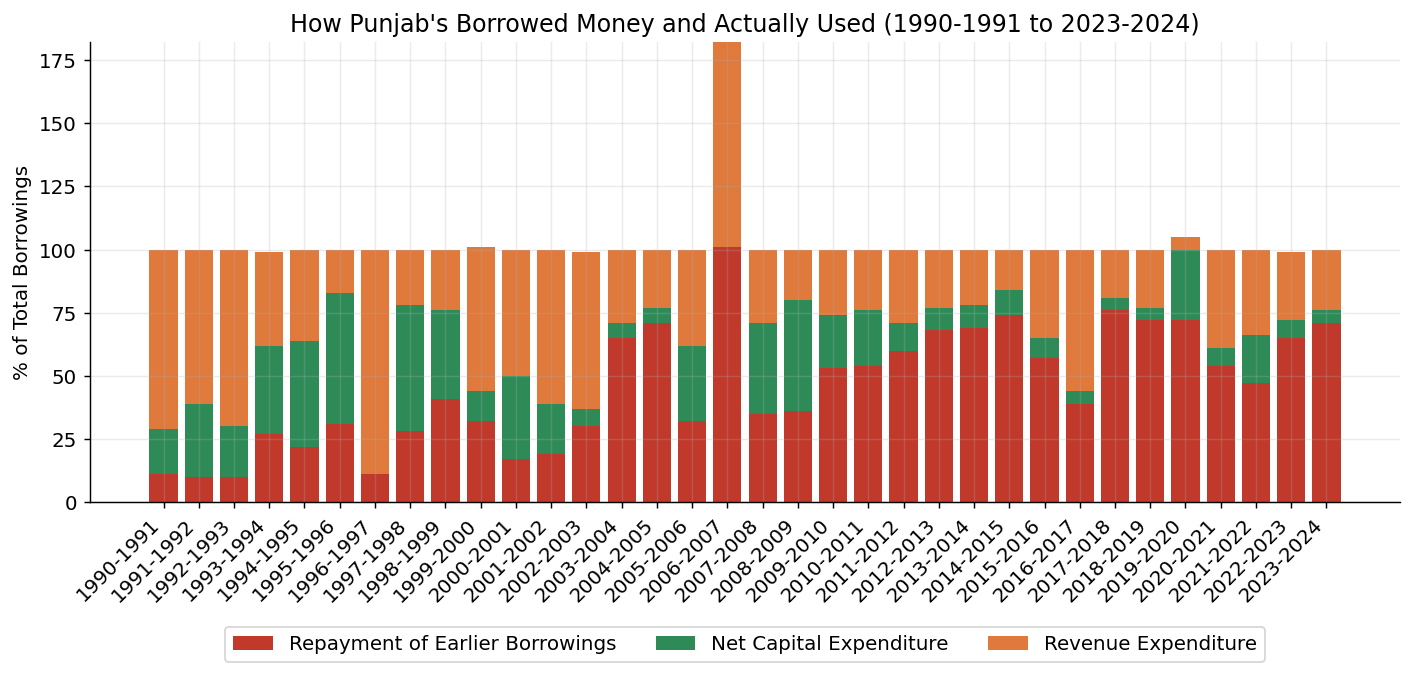

In [79]:
# Stacked percentage bar chart
plt.rcParams.update({"figure.dpi": 130, "font.size": 11,
                      "axes.spines.top": False, "axes.spines.right": False,
                      "axes.grid": True, "grid.alpha": 0.25})

years = table.index.tolist()
x = range(len(years))
repay_pct = table["Repayment %"]
capex_pct = table["Capex %"]
revexp_pct = table["Revenue Exp %"]

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.bar(x, repay_pct, label="Repayment of Earlier Borrowings", color="#c0392b")
ax.bar(x, capex_pct, bottom=repay_pct, label="Net Capital Expenditure", color="#2e8b57")
ax.bar(x, revexp_pct, bottom=repay_pct + capex_pct, label="Revenue Expenditure", color="#e0793c")
ax.set_title(f"How {STATE}'s Borrowed Money and Actually Used ({START_YEAR} to {END_YEAR})")
ax.set_ylabel("% of Total Borrowings")
ax.set_xticks(list(x))
ax.set_xticklabels(years, rotation=45, ha="right")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.25), ncol=3)
fig.tight_layout()
fig.savefig(f"{STATE.lower()}_borrowed_funds_utilisation.png", bbox_inches="tight")

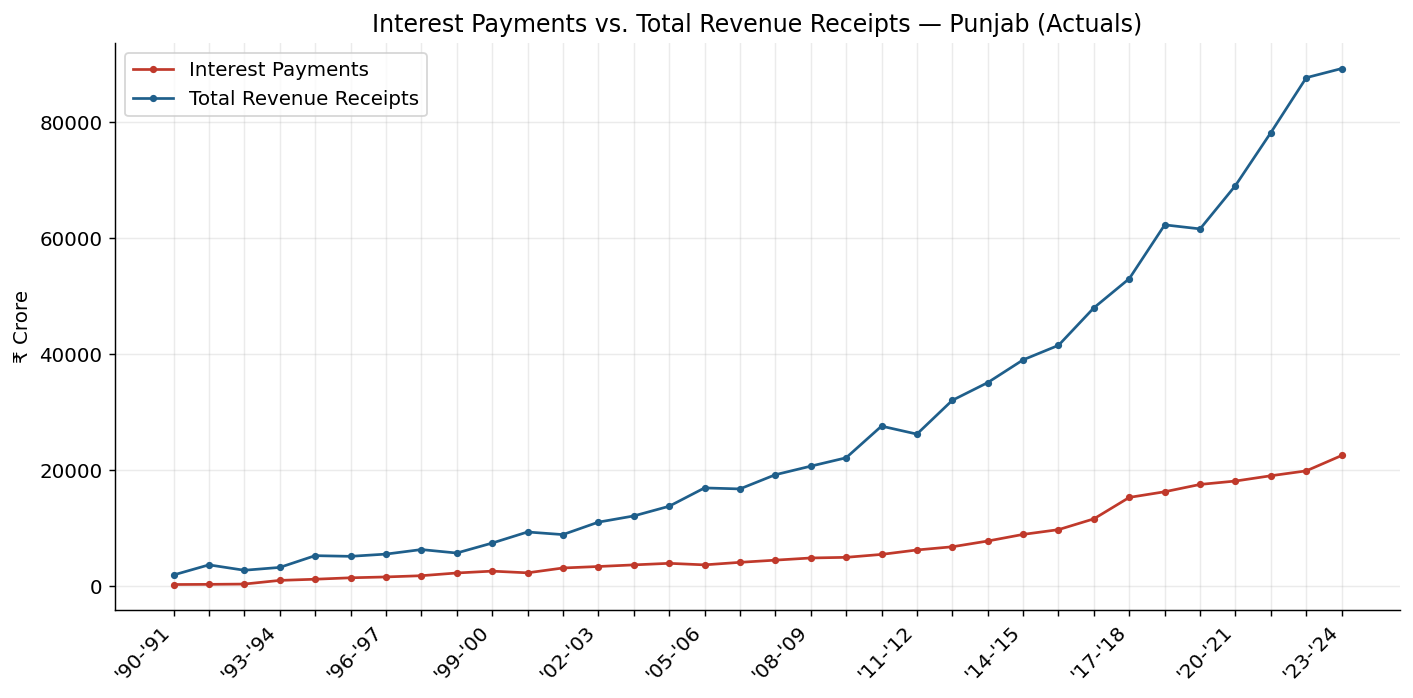

In [80]:
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(x, interest, marker="o", markersize=3, label="Interest Payments", color=COLOR_C)
ax.plot(x, revenue, marker="o", markersize=3, label="Total Revenue Receipts", color=COLOR_A)
ax.set_title("Interest Payments vs. Total Revenue Receipts — Punjab (Actuals)")
ax.set_ylabel("₹ Crore")
thin_xticks(ax, years_short, step=3)
ax.legend()
plt.tight_layout()
plt.show()

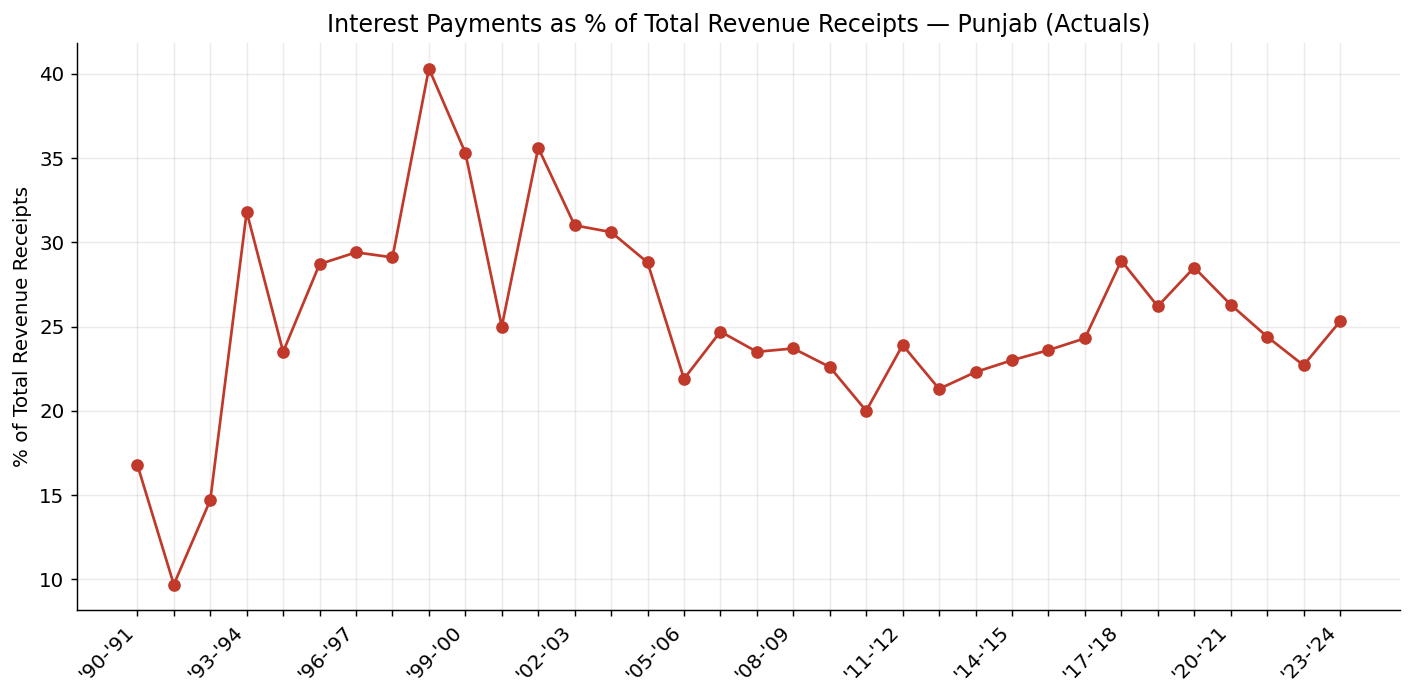

In [81]:
interest_pct_revenue = (interest / revenue * 100).round(1)

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(x, interest_pct_revenue, marker="o", color=COLOR_C)
ax.set_title("Interest Payments as % of Total Revenue Receipts — Punjab (Actuals)")
ax.set_ylabel("% of Total Revenue Receipts")
thin_xticks(ax, years_short, step=3)
plt.tight_layout()
plt.show()

In [82]:
import pandas as pd
import matplotlib.pyplot as plt

INPUT_FILE = "state_finance_analysis.XLSX"
peers = ["Punjab", "Kerala", "Rajasthan", "West Bengal", "Himachal Pradesh", "Andhra Pradesh"]
COLOR_PEER = {"Punjab": "#c0392b", "Kerala": "#e0793c", "Rajasthan": "#2e8b57",
              "West Bengal": "#6a4c93", "Himachal Pradesh": "#1f5f8b", "Andhra Pradesh": "#999999"}

In [83]:
HEADS = [
    "Total: TOTAL REVENUE (I+II)",
    "Total: TOTAL EXPENDITURE (I+II+III)",
    "II.C.2: Interest Payments (i to iv)",
    "II: Discharge of Internal Debt (1 to 8)",
    "I: Total Capital Outlay (1 + 2)",
    "A: Surplus (+)/Deficit (-) on Revenue Account",
]

In [84]:
def load_all_states(path):
    df = pd.read_excel(path, sheet_name="Data")
    return df[df["Budget Head"].isin(HEADS)][["State/UT", "Budget Head", "Fiscal Year", "Account"]]

In [85]:
def year_pivot(sub, year):
    d = sub[sub["Fiscal Year"] == year]
    return d.pivot_table(index="State/UT", columns="Budget Head", values="Account", aggfunc="first")

In [86]:
def metrics_for_year(piv):
    rev = piv["Total: TOTAL REVENUE (I+II)"]
    exp = piv["Total: TOTAL EXPENDITURE (I+II+III)"]
    interest = piv["II.C.2: Interest Payments (i to iv)"]
    capout = piv["I: Total Capital Outlay (1 + 2)"]
    revdef = piv["A: Surplus (+)/Deficit (-) on Revenue Account"]
    return pd.DataFrame({
        "Interest_pct_Revenue": (interest / rev * 100).round(1),
        "Interest_to_CapOutlay": (interest / capout).round(2),
        "CapOutlay_pct_Expenditure": (capout / exp * 100).round(1),
        "RevDeficit_pct_Revenue": (revdef / rev * 100).round(1),
    })

In [87]:
sub = load_all_states(INPUT_FILE)
years = [f"{y}-{y+1}" for y in range(1990, 2024)]

In [88]:
metric_titles = {
    "Interest_pct_Revenue": "Interest Payments % of Revenue — Punjab vs. Other States",
    "Interest_to_CapOutlay": "Interest ÷ Capital Outlay — Punjab vs. Other States",
    "CapOutlay_pct_Expenditure": "Capital Outlay % of Expenditure — Punjab vs. Other States",
    "RevDeficit_pct_Revenue": "Revenue Deficit % of Revenue — Punjab vs. Other States",
}
metric_ylabels = {
    "Interest_pct_Revenue": "% of Total Revenue",
    "Interest_to_CapOutlay": "Interest / Capital Outlay (x)",
    "CapOutlay_pct_Expenditure": "% of Total Expenditure",
    "RevDeficit_pct_Revenue": "% of Total Revenue (negative = deficit)",
}

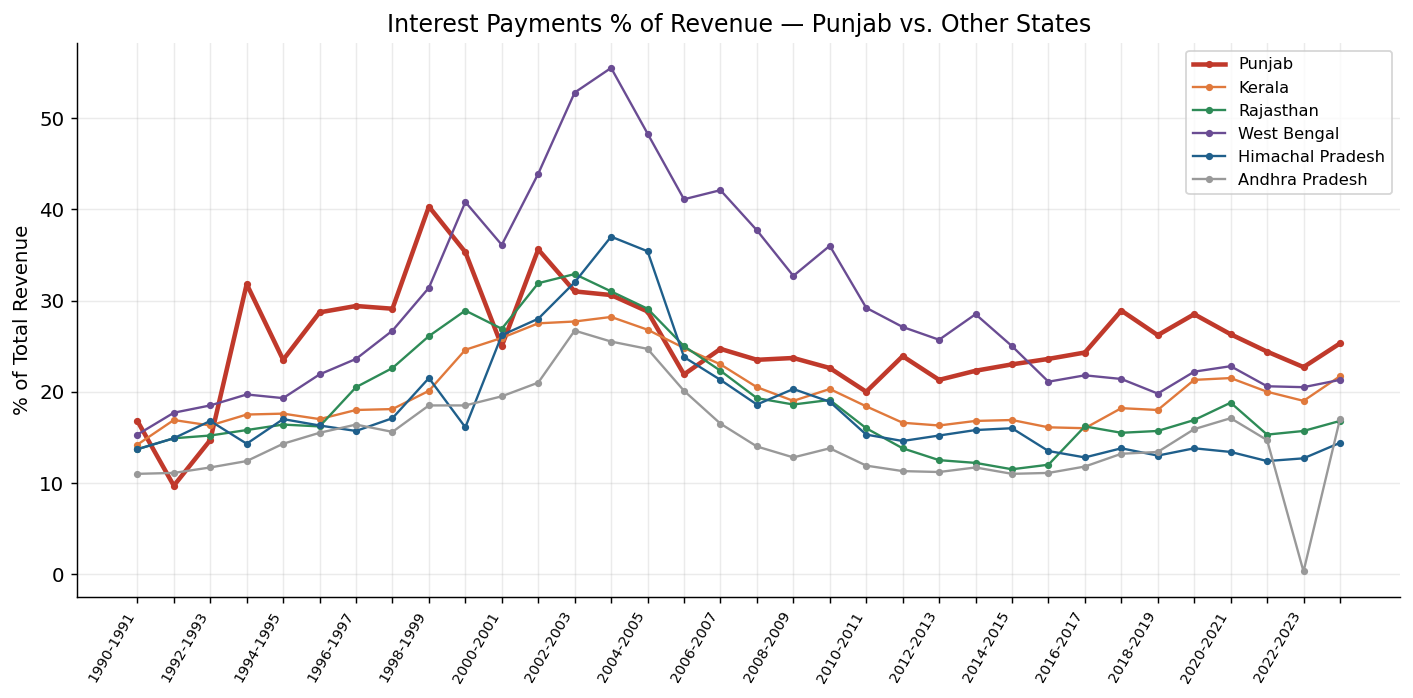

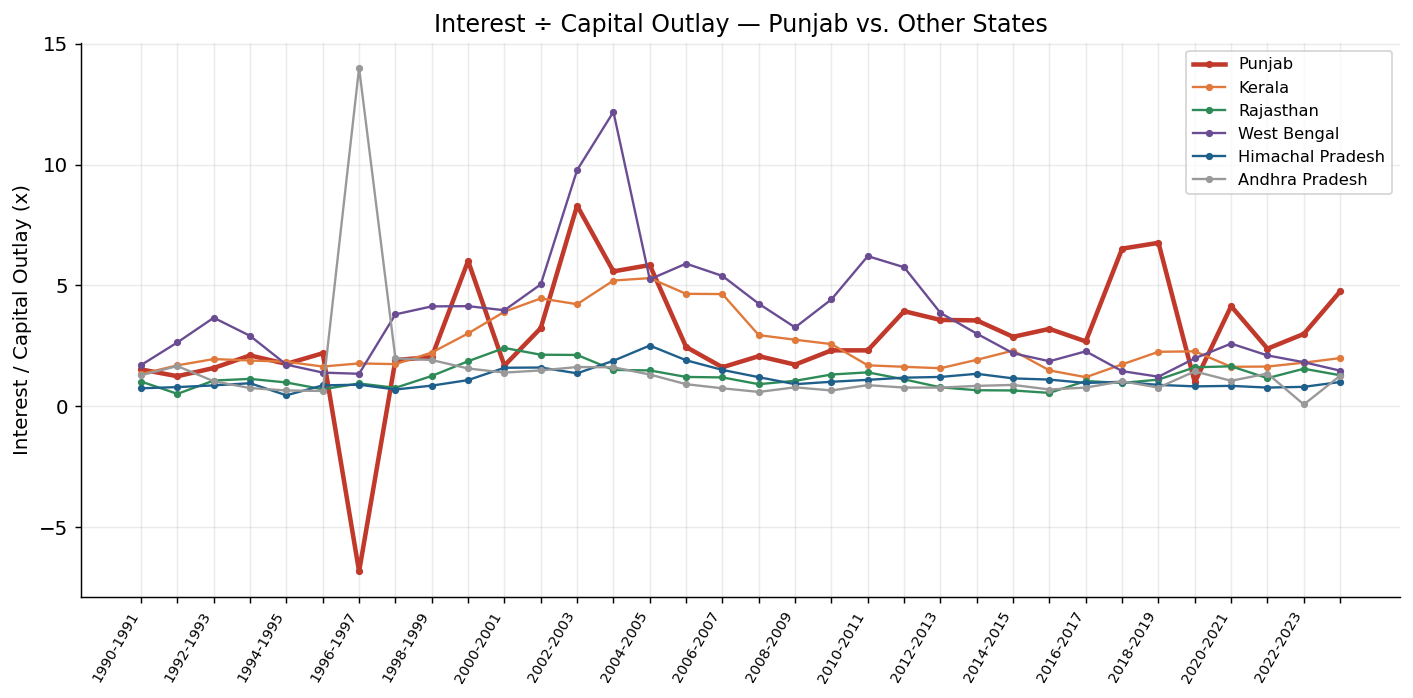

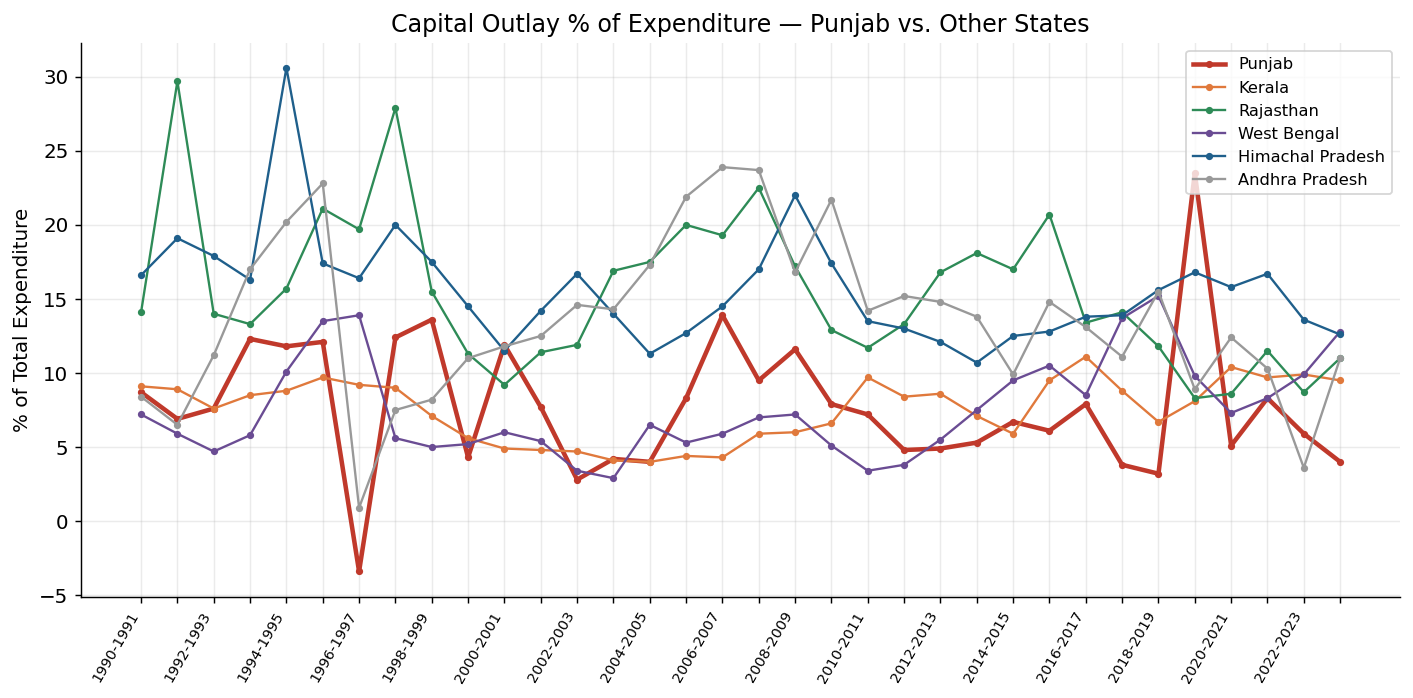

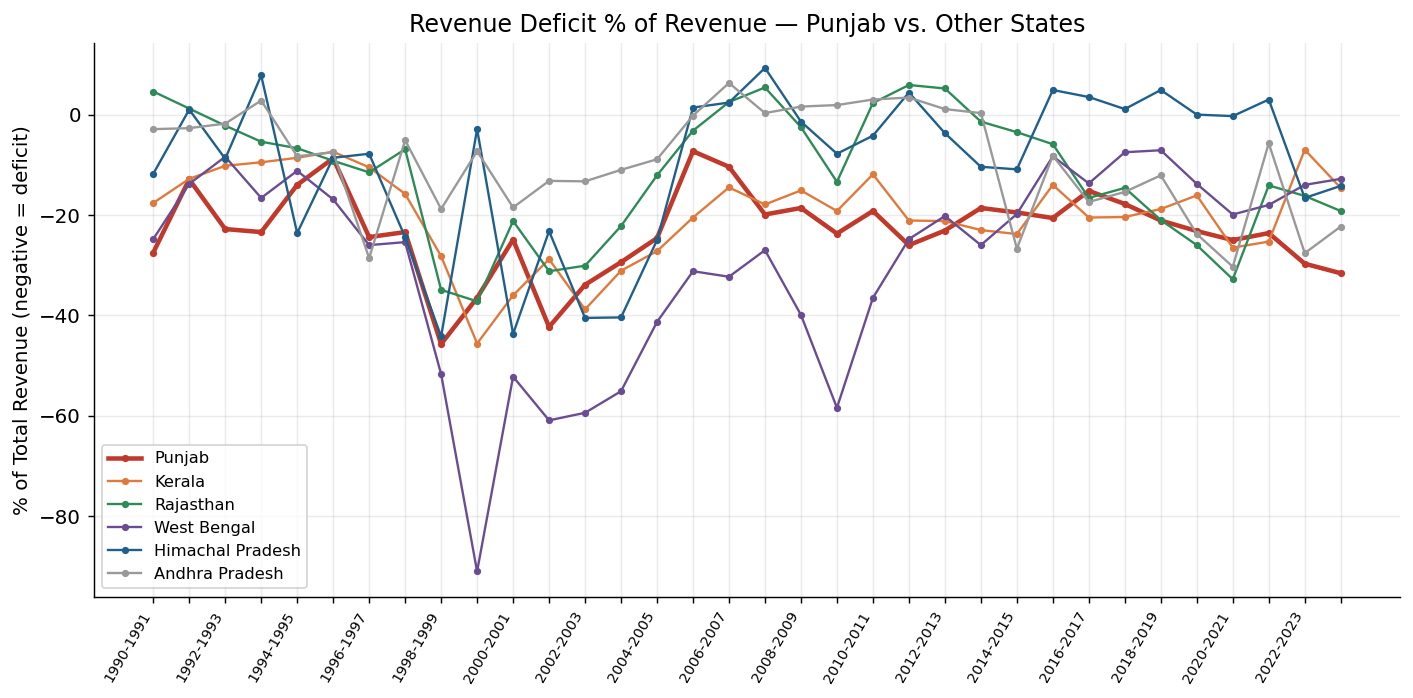

In [89]:
for metric in metric_titles:
    rows = []
    for Y in years:
        piv = year_pivot(sub, Y)
        if "Total: TOTAL REVENUE (I+II)" not in piv.columns:
            continue
        m = metrics_for_year(piv)
        for p in peers:
            if p in m.index and pd.notna(m.loc[p, metric]):
                rows.append({"Year": Y, "State": p, "Value": m.loc[p, metric]})

    peer_df = pd.DataFrame(rows)
    peer_pivot = peer_df.pivot(index="Year", columns="State", values="Value")

    fig, ax = plt.subplots(figsize=(11, 5.5))
    for p in peers:
        if p in peer_pivot.columns:
            ax.plot(range(len(peer_pivot)), peer_pivot[p], marker="o", markersize=3,
                    label=p, color=COLOR_PEER.get(p, "#888888"),
                    linewidth=2.5 if p == "Punjab" else 1.3)
    ax.set_title(metric_titles[metric])
    ax.set_ylabel(metric_ylabels[metric])
    ax.set_xticks(range(len(peer_pivot)))
    ax.set_xticklabels([y if i % 2 == 0 else "" for i, y in enumerate(peer_pivot.index)],
                        rotation=60, ha="right", fontsize=8)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

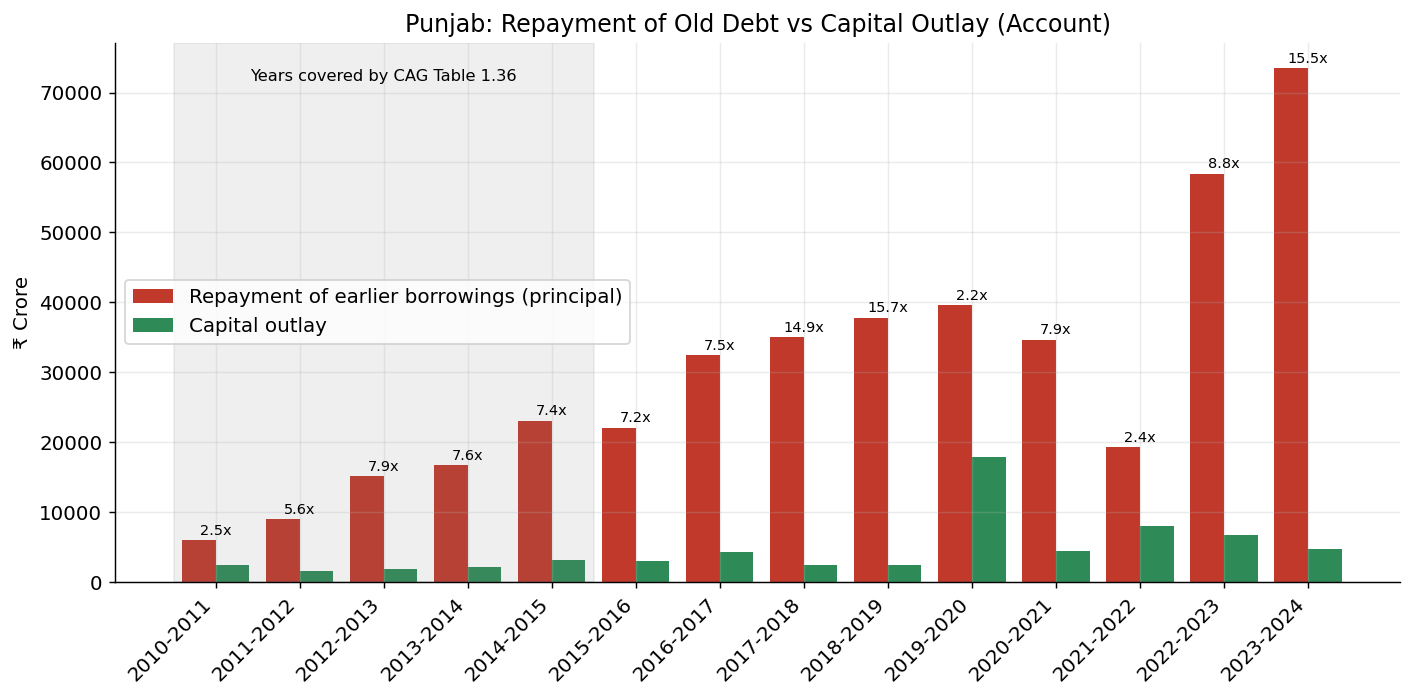

In [111]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel("state_finance_analysis.XLSX", sheet_name="Data")
pb = df[df["State/UT"] == "Punjab"]
heads = ["II: Discharge of Internal Debt (1 to 8)",
         "III: Repayment of Loans to the Centre (1 to 7)",
         "I: Total Capital Outlay (1 + 2)"]
p = pb[pb["Budget Head"].isin(heads)].pivot_table(
    index="Fiscal Year", columns="Budget Head", values="Account", aggfunc="first")

d = pd.DataFrame({"Repayment": p[heads[0]] + p[heads[1]],
                  "CapOutlay": p[heads[2]]}).loc["2010-2011":"2023-2024"]
d["Ratio"] = d["Repayment"] / d["CapOutlay"]

x = list(range(len(d))); w = 0.4
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.bar([i - w/2 for i in x], d["Repayment"], w, color="#c0392b",
       label="Repayment of earlier borrowings (principal)")
ax.bar([i + w/2 for i in x], d["CapOutlay"], w, color="#2e8b57", label="Capital outlay")
for i, r in enumerate(d["Ratio"]):
    ax.text(i, d["Repayment"].iloc[i] + 800, f"{r:.1f}x", ha="center", fontsize=8)
ax.axvspan(-0.5, 4.5, color="grey", alpha=0.12)
ax.text(2, ax.get_ylim()[1] * 0.93, "Years covered by CAG Table 1.36", ha="center", fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(d.index, rotation=45, ha="right")
ax.set_ylabel("₹ Crore")
ax.set_title("Punjab: Repayment of Old Debt vs Capital Outlay (Account)")
ax.legend()
plt.tight_layout()
plt.show()

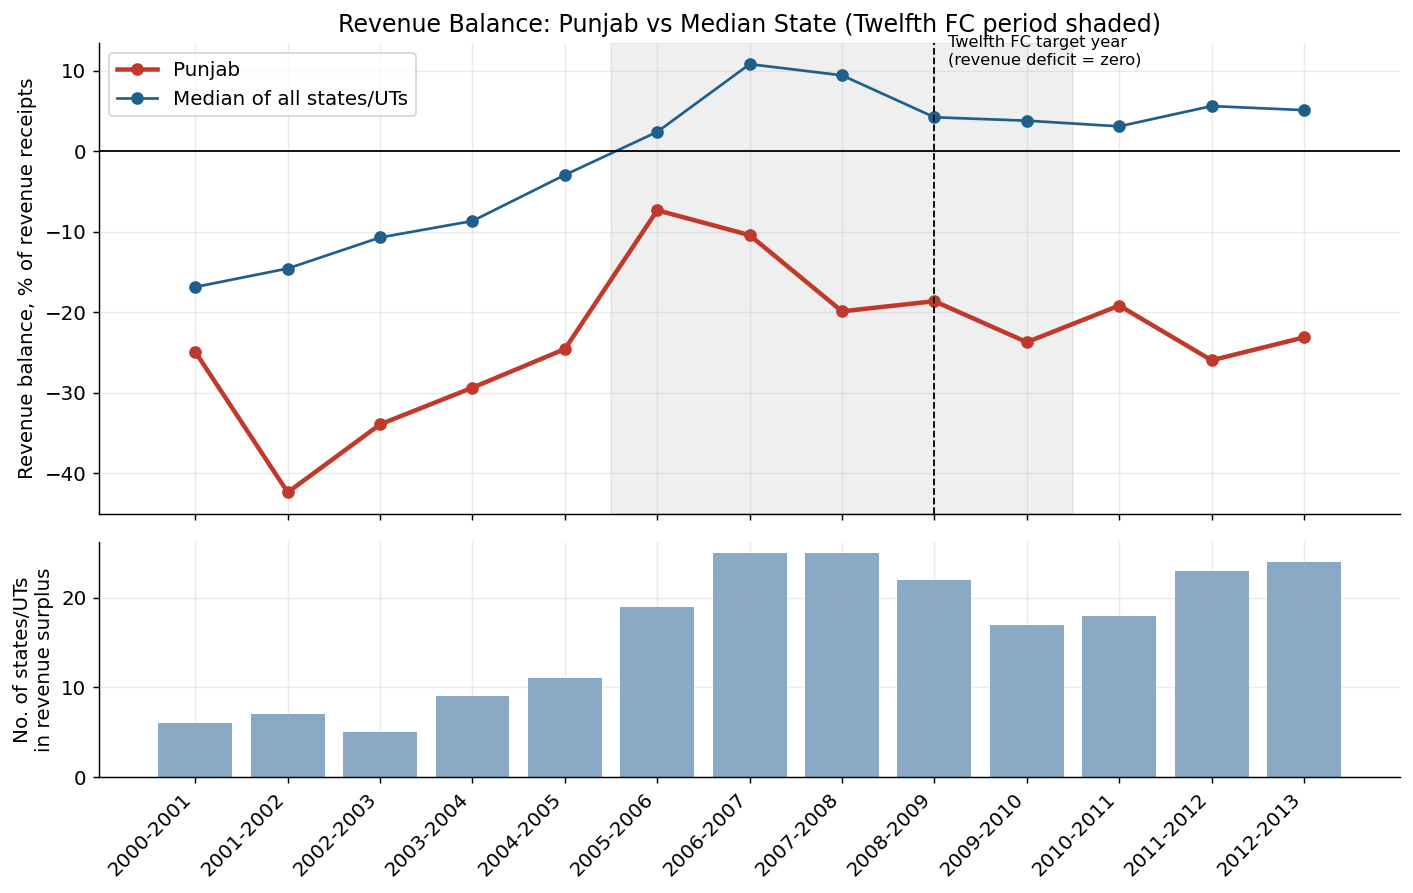

In [91]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel("state_finance_analysis.XLSX", sheet_name="Data")
h = ["A: Surplus (+)/Deficit (-) on Revenue Account", "Total: TOTAL REVENUE (I+II)"]
s = df[df["Budget Head"].isin(h) & (df["State/UT"] != "All States/UT")]
piv = s.pivot_table(index=["Fiscal Year", "State/UT"], columns="Budget Head",
                    values="Account", aggfunc="first").dropna()
piv["pct"] = piv[h[0]] / piv[h[1]] * 100
pct = piv["pct"].unstack("State/UT")

years = [f"{y}-{y+1}" for y in range(2000, 2013)]
pct = pct.loc[years]
punjab = pct["Punjab"]
median = pct.median(axis=1)
n_surplus = (pct >= 0).sum(axis=1)

x = list(range(len(years)))
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True,
                               gridspec_kw={"height_ratios": [2, 1]})
ax1.plot(x, punjab, marker="o", color="#c0392b", linewidth=2.5, label="Punjab")
ax1.plot(x, median, marker="o", color="#1f5f8b", label="Median of all states/UTs")
ax1.axhline(0, color="black", linewidth=1)
ax1.axvspan(years.index("2005-2006") - 0.5, years.index("2009-2010") + 0.5,
            color="grey", alpha=0.12)
ax1.axvline(years.index("2008-2009"), color="black", linestyle="--", linewidth=1)
ax1.text(years.index("2008-2009") + 0.15, ax1.get_ylim()[1] * 0.8,
         "Twelfth FC target year\n(revenue deficit = zero)", fontsize=9)
ax1.set_ylabel("Revenue balance, % of revenue receipts")
ax1.set_title("Revenue Balance: Punjab vs Median State (Twelfth FC period shaded)")
ax1.legend()

ax2.bar(x, n_surplus, color="#8aa9c4")
ax2.set_ylabel("No. of states/UTs\nin revenue surplus")
ax2.set_xticks(x)
ax2.set_xticklabels(years, rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [92]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel("state_finance_analysis.XLSX", sheet_name="Data")
states = df[df["State/UT"] != "All States/UT"]

def allstates(head):
    return states[states["Budget Head"] == head].pivot_table(
        index="Fiscal Year", columns="State/UT", values="Account", aggfunc="first")

rev  = allstates("Total: TOTAL REVENUE (I+II)")
exp  = allstates("Total: TOTAL EXPENDITURE (I+II+III)")
intr = allstates("II.C.2: Interest Payments (i to iv)")
pen  = allstates("II.E: Pensions")
dis  = allstates("II: Discharge of Internal Debt (1 to 8)")
cap  = allstates("I: Total Capital Outlay (1 + 2)")
rdef = allstates("A: Surplus (+)/Deficit (-) on Revenue Account")

             Interest  Pensions  Repayment  Total
Fiscal Year                                      
1990-1991        16.8       6.4        0.4   23.7
2000-2001        25.0      11.9        0.8   37.7
2010-2011        20.0      19.2       20.9   60.1
2015-2016        23.6      18.9       52.3   94.8
2020-2021        26.3      19.8       49.5   95.6
2023-2024        25.3      22.5       81.7  129.5


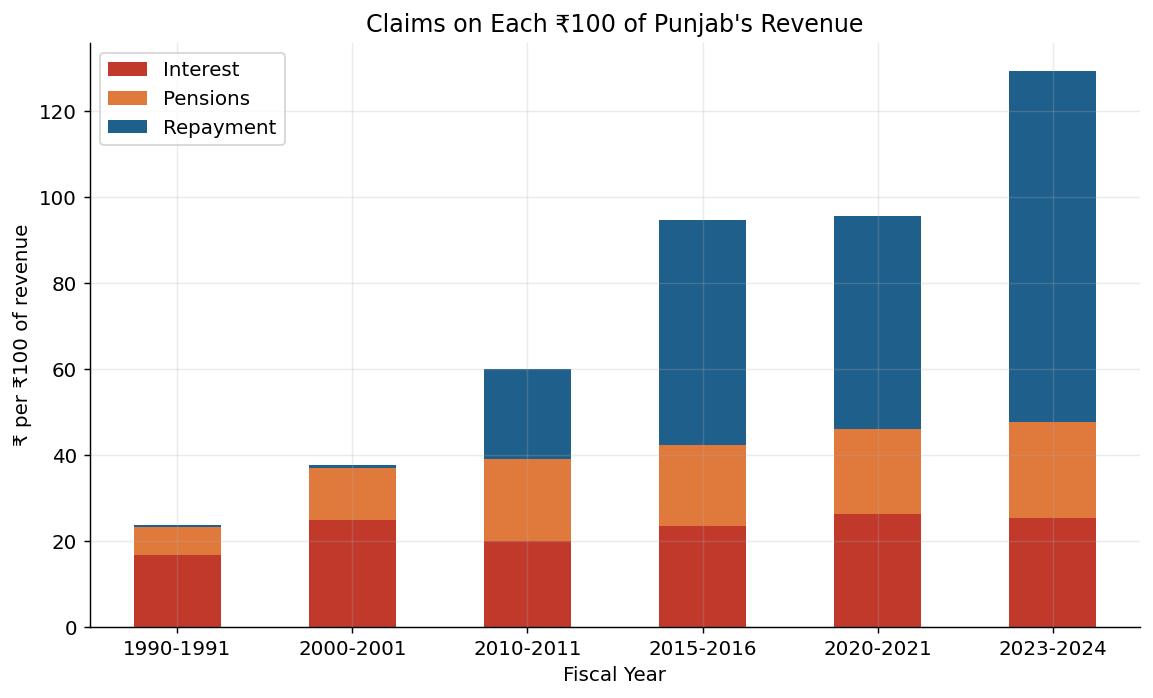

In [112]:
t = pd.DataFrame({"Interest":  intr["Punjab"] / rev["Punjab"] * 100,
                  "Pensions":  pen["Punjab"]  / rev["Punjab"] * 100,
                  "Repayment": dis["Punjab"]  / rev["Punjab"] * 100})
sel = t.loc[["1990-1991", "2000-2001", "2010-2011", "2015-2016", "2020-2021", "2023-2024"]]
sel["Total"] = sel.sum(axis=1)
print(sel.round(1))

ax = sel[["Interest", "Pensions", "Repayment"]].plot(
    kind="bar", stacked=True, figsize=(9, 5.5), color=["#c0392b", "#e0793c", "#1f5f8b"])

ax.set_ylabel("₹ per ₹100 of revenue")
ax.set_title("Claims on Each ₹100 of Punjab's Revenue")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

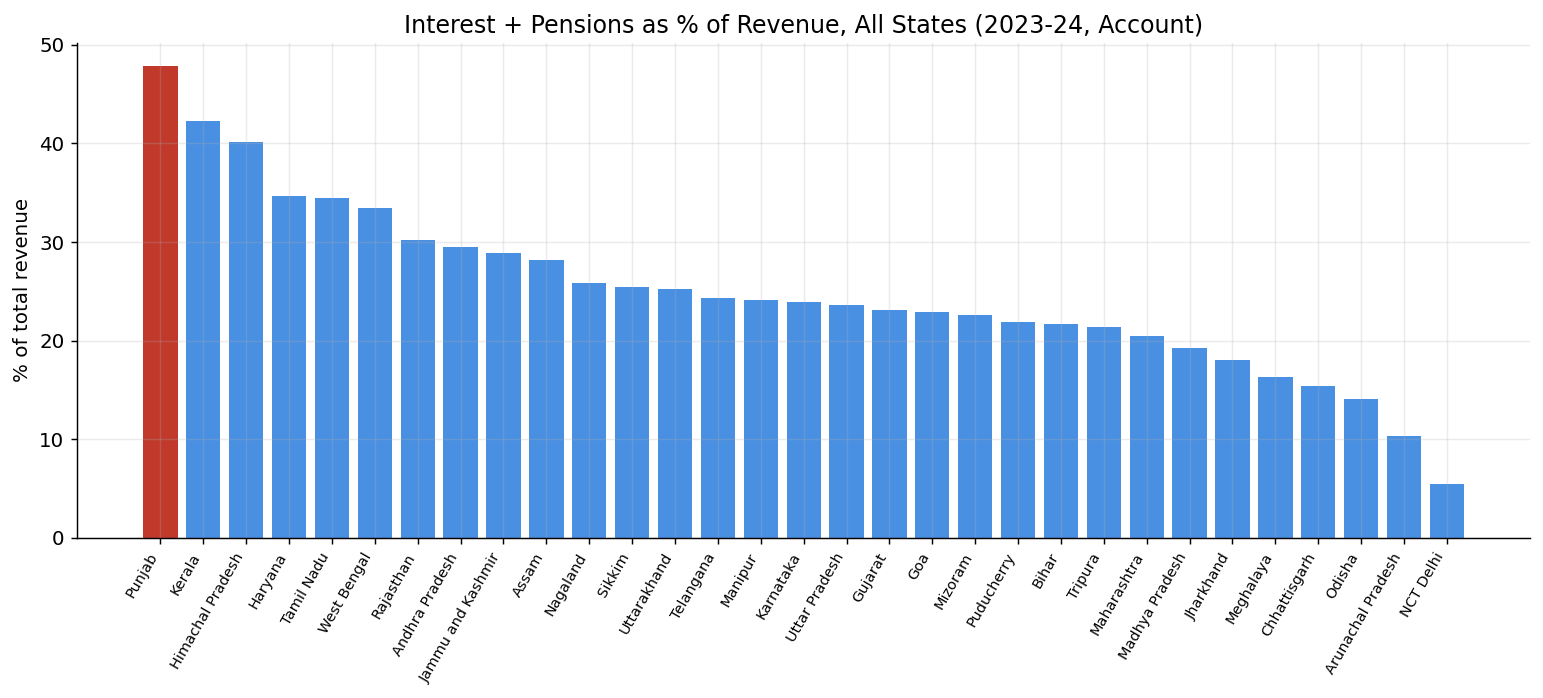

In [101]:
Y = "2023-2024"
s = ((intr.loc[Y] + pen.loc[Y]) / rev.loc[Y] * 100).dropna().sort_values(ascending=False)
colors = ["#c0392b" if n == "Punjab" else "#4a90e2" for n in s.index]
plt.figure(figsize=(12, 5.5))
plt.bar(range(len(s)), s.values, color=colors)
plt.xticks(range(len(s)), s.index, rotation=60, ha="right", fontsize=8)
plt.ylabel("% of total revenue")
plt.title("Interest + Pensions as % of Revenue, All States (2023-24, Account)")
plt.tight_layout(); plt.show()

Debt service/Revenue    10
Interest/Revenue         9
Interest/Capex           9
Capex/Expenditure        7
Rev deficit/Revenue      5
dtype: int64
Fiscal Year
2010-2011    0
2011-2012    1
2012-2013    3
2013-2014    3
2014-2015    2
2015-2016    4
2016-2017    4
2017-2018    4
2018-2019    5
2019-2020    2
2020-2021    2
2021-2022    1
2022-2023    4
2023-2024    5
dtype: int64


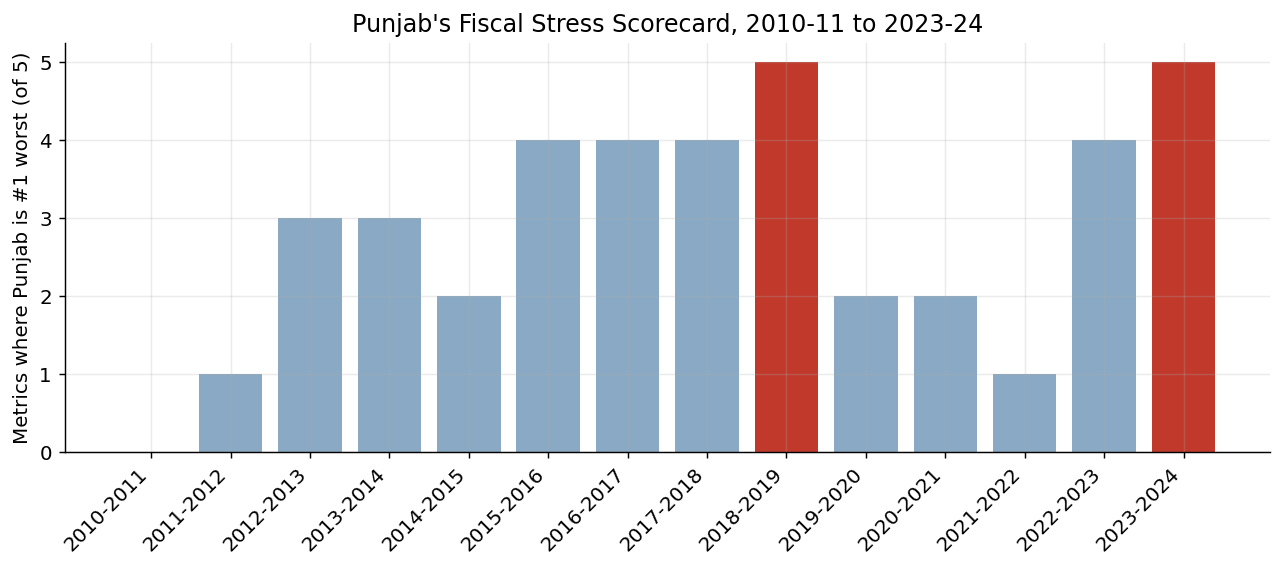

In [95]:
M = {"Debt service/Revenue": ((intr + dis) / rev, False),
     "Interest/Revenue":     (intr / rev, False),
     "Interest/Capex":       (intr / cap, False),
     "Capex/Expenditure":    (cap / exp, True),
     "Rev deficit/Revenue":  (rdef / rev, True)}
ranks = pd.DataFrame({k: v.rank(axis=1, ascending=a)["Punjab"] for k, (v, a) in M.items()})
win = ranks.loc["2010-2011":"2023-2024"]
print((win == 1).sum())              # years as #1 out of 14
n1 = (win == 1).sum(axis=1)
print(n1)

plt.figure(figsize=(10, 4.5))
plt.bar(range(len(n1)), n1, color=["#c0392b" if v == 5 else "#8aa9c4" for v in n1])
plt.xticks(range(len(n1)), n1.index, rotation=45, ha="right")
plt.ylabel("Metrics where Punjab is #1 worst (of 5)")
plt.title("Punjab's Fiscal Stress Scorecard, 2010-11 to 2023-24")
plt.tight_layout(); plt.show()

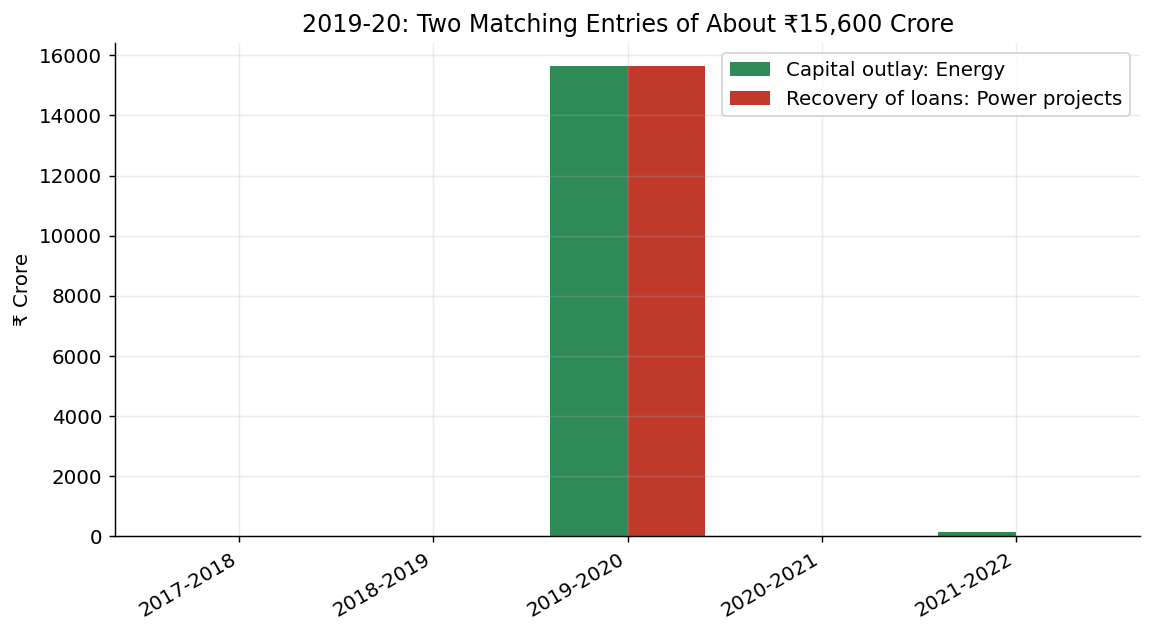

Capex share reported: 23.5  adjusted: 3.7


In [113]:
yrs = ["2017-2018", "2018-2019", "2019-2020", "2020-2021", "2021-2022"]
en  = allstates("I.1.b.5: Energy")["Punjab"].loc[yrs]
rec = allstates("III.7: Power Projects")["Punjab"].loc[yrs]
bw = 0.4; x = range(len(yrs))
plt.figure(figsize=(9, 5))
plt.bar([i - bw/2 for i in x], en,  bw, color="#2e8b57", label="Capital outlay: Energy")
plt.bar([i + bw/2 for i in x], rec, bw, color="#c0392b", label="Recovery of loans: Power projects")
plt.xticks(list(x), yrs, rotation=30, ha="right"); plt.ylabel("₹ Crore")
plt.title("2019-20: Two Matching Entries of About ₹15,600 Crore"); plt.legend()
plt.tight_layout(); plt.show()

conv = 15628
cp, ep = cap["Punjab"]["2019-2020"], exp["Punjab"]["2019-2020"]
print("Capex share reported:", round(cp / ep * 100, 1), " adjusted:", round((cp - conv) / (ep - conv) * 100, 1))

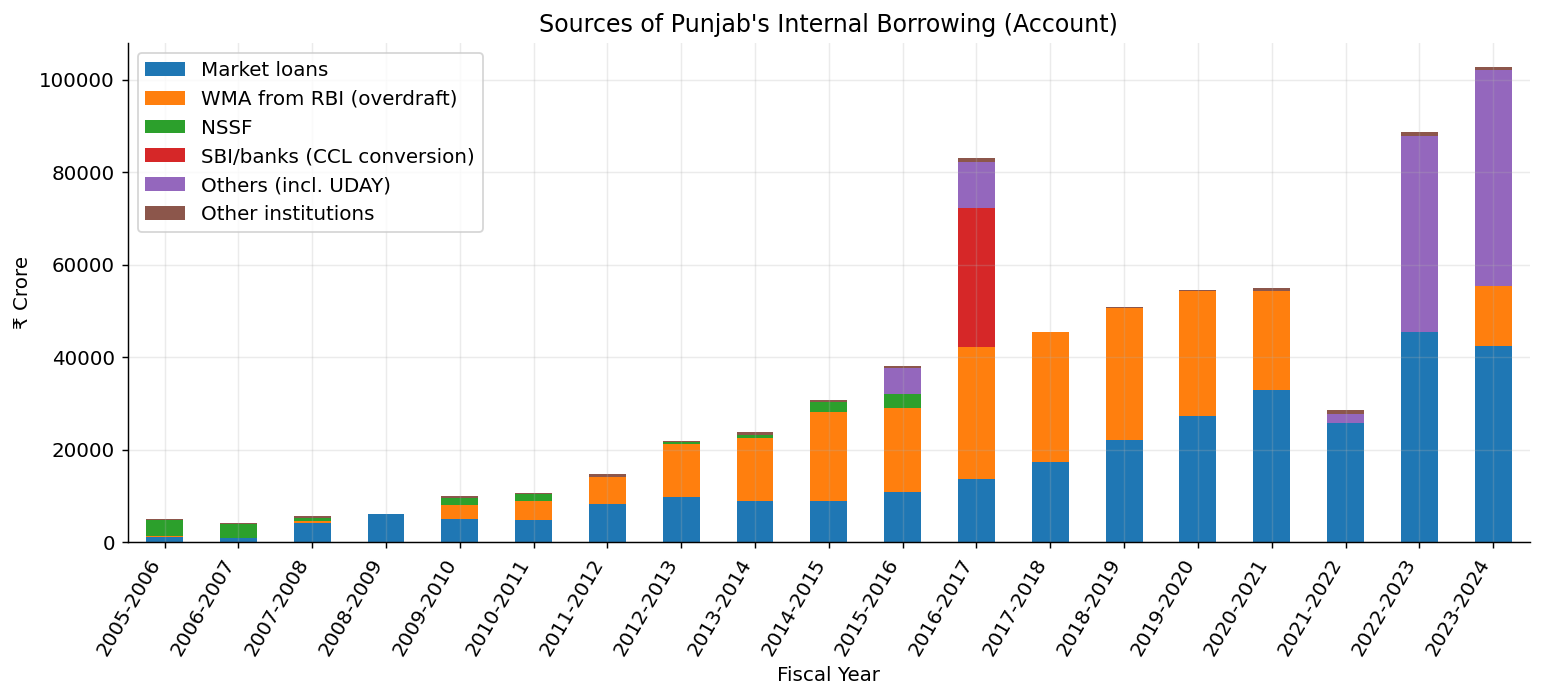

In [100]:
def pj(head): return allstates(head)["Punjab"]
src = {"Market loans": "I.1: Market Loans",
       "WMA from RBI (overdraft)": "I.6: WMA from RBI",
       "NSSF": "I.7: Special Securities issued to NSSF",
       "SBI/banks (CCL conversion)": "I.4: Loans from SBI and other Banks",
       "Others (incl. UDAY)": "I.8: Others (including 106)"}
d = pd.DataFrame({k: pj(v) for k, v in src.items()}).fillna(0)
d["Other institutions"] = pj("I: Internal Debt (1 to 8)") - d.sum(axis=1)
d = d.loc["2005-2006":"2023-2024"]
ax = d.plot(kind="bar", stacked=True, figsize=(12, 5.5))
ax.set_ylabel("₹ Crore"); ax.set_title("Sources of Punjab's Internal Borrowing (Account)")
plt.xticks(rotation=60, ha="right"); plt.tight_layout(); plt.show()

In [98]:
yrs = [f"{y}-{y+1}" for y in range(2010, 2024)]
T = pd.DataFrame({"Revenue": rev["Punjab"], "Interest": intr["Punjab"],
                  "Pensions": pen["Punjab"], "Capital outlay": cap["Punjab"]}).loc[yrs].sum()
print(T.round(0))
print((T / T["Revenue"] * 100).round(1))
print("Capex excluding PSPCL conversion:", round(T["Capital outlay"] - 15628))

Revenue           750408.0
Interest          185710.0
Pensions          144371.0
Capital outlay     65017.0
dtype: float64
Revenue           100.0
Interest           24.7
Pensions           19.2
Capital outlay      8.7
dtype: float64
Capex excluding PSPCL conversion: 49389
